<a href="https://colab.research.google.com/github/IgorKovacevicENNOH/ENNOH_Modelling/blob/main/Modular_Model_II.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
! pip install pypsa highspy gurobipy openpyxl "xarray<=2024.9.0"

In [2]:
# Setup fresh Gurobi Environment with WLS license parameters
import gurobipy as gp

try:
    # Create a dictionary for WLS parameters
    params = {
        "WLSACCESSID": '93715342-715e-4351-8871-27269c0410a3',
        "WLSSECRET": '1eedad4a-f864-49fd-a512-4a29921a2780',
        "LICENSEID": 2854029
    }
    # Initialize environment explicitly
    env = gp.Env(params=params)
except Exception as e:
    print(f"Error initializing Gurobi environment: {e}")
    env = None

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2854029
WLS license 2854029 - registered to European Network of Network Operators for Hydrogen


In [3]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


# 0, Importing Model Data

The following cell demonstrates how to initialize the model using only the files saved in `MODEL_DATA_DIR`.

In [4]:
# Import packages
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import openpyxl
import json
import time
import pypsa
import warnings

ROOT_DIR = os.getcwd()
PROJECT_DIR = os.path.join(ROOT_DIR, "drive/MyDrive/Colab_Notebooks/ENNOH/Zonal_model")

In [5]:
sys.path.append(PROJECT_DIR)

from modules.getting_input_data import get_input_data, load_model_data

input_file_name = "input_file.xlsx"
input_data = get_input_data(PROJECT_DIR, input_file_name)


File found at: /content/drive/MyDrive/Colab_Notebooks/ENNOH/Zonal_model/input_file.xlsx
The input data has been imported.


In [6]:
MODEL_DATA_DIR = os.path.join(PROJECT_DIR, str(input_data['data_set']), input_data['model_data_dir'], input_data['project_name'], input_data['scenario'], str(input_data['year']), f'profile_{input_data["weather_profile"]}')

RESULTS_DIR = os.path.join(PROJECT_DIR, str(input_data['data_set']),
    input_data['result_dir'], input_data['project_name'],
    input_data['scenario'], str(input_data['year']), f'profile_{input_data["weather_profile"]}')

In [7]:
print(f"MODEL_DATA_DIR: {MODEL_DATA_DIR}")
print(f"RESULTS_DIR: {RESULTS_DIR}")

MODEL_DATA_DIR: /content/drive/MyDrive/Colab_Notebooks/ENNOH/Zonal_model/TYNDP_scenario_2026/model_data/Europe/DE/2035/profile_1
RESULTS_DIR: /content/drive/MyDrive/Colab_Notebooks/ENNOH/Zonal_model/TYNDP_scenario_2026/results/Europe/DE/2035/profile_1


In [8]:
model_data = load_model_data(MODEL_DATA_DIR)

✅ Successfully imported and reconstructed model_data from: /content/drive/MyDrive/Colab_Notebooks/ENNOH/Zonal_model/TYNDP_scenario_2026/model_data/Europe/DE/2035/profile_1


# 1, Resampling Data

In [9]:
# Set global resampling frequency
resample_freq = "24h"
resample_freq_hours = float(pd.Timedelta(resample_freq).total_seconds() / 3600)
print(f"Target Resampling: {resample_freq} ({resample_freq_hours} hours)")

Target Resampling: 24h (24.0 hours)


In [10]:

# Convert frequency string to float number of hours
resample_freq_hours = float(pd.Timedelta(resample_freq).total_seconds() / 3600)

In [11]:
h2_demand_series = pd.Series(model_data['Zonal']['DE00']['H2_demand']['DEh2'])
h2_demand_series.index = pd.to_datetime(h2_demand_series.index)
resampled_h2_demand = h2_demand_series.resample(resample_freq).sum()
new_snapshots = resampled_h2_demand.index
print(f"Created new_snapshots with length: {len(new_snapshots)}")

Created new_snapshots with length: 365


In [12]:
def dict_to_resampled_df(profiles_dict: dict, snapshots: pd.DatetimeIndex, freq: str = '24h', default_agg: str = 'mean', specific_aggs: dict = None) -> pd.DataFrame:
    """
    Transforms a dictionary of time-series profiles into a resampled pandas DataFrame
    suitable for PyPSA time-dependent attributes, strictly aligned to network snapshots.
    Drops duplicate timestamps to prevent reindexing errors.
    """
    fixed_ts = {}
    year = snapshots.year[0] if len(snapshots) > 0 else 2030
    full_year_index = pd.date_range(start=f"{year}-01-01 00:00", periods=8760, freq='h')

    for k, v in profiles_dict.items():
        if not isinstance(v, (pd.Series, dict, np.ndarray, list)):
            continue

        s = pd.Series(v) if not isinstance(v, pd.Series) else v.copy()

        if not isinstance(s.index, pd.DatetimeIndex):
            if len(s) == 8760:
                s.index = full_year_index
            elif len(s) == len(snapshots):
                s.index = snapshots
            else:
                try:
                    # Added format='mixed' to suppress the dateutil fallback warning
                    s.index = pd.to_datetime(s.index, errors='coerce', format='mixed')
                except:
                    continue

        # Fix for duplicate labels causing reindex ValueError
        if not s.index.is_unique:
            s = s[~s.index.duplicated(keep='first')]

        fixed_ts[k] = s

    if not fixed_ts:
        return pd.DataFrame(index=snapshots)

    df = pd.DataFrame(fixed_ts)

    if specific_aggs is None:
        specific_aggs = {}

    agg_mapping = {col: specific_aggs.get(col, default_agg) for col in df.columns}
    df_resampled = df.resample(freq).agg(agg_mapping)
    df_aligned = df_resampled.reindex(snapshots).fillna(0)

    return df_aligned

# 2, Skeleton Model



## Carriers

In [13]:
def add_carriers(n):
  carriers = ['AC', 'H2', 'natural_gas', 'CO2', 'SNG', 'e-Kerosene', 'e-Diesel',
              'hard_coal', 'lignite', 'oil', 'hydro', 'battery', 'nuclear', 'heat']
  for c in carriers:
    n.add('Carrier', c)
  return n


## Global/Europe level

In [14]:
# buses
def add_global_buses(n, input_data):
    """Initializes global/europe market buses with unified naming"""
    n.add("Bus", "hard_coal_market", carrier="hard_coal")
    n.add("Bus", "lignite_market", carrier="lignite")
    n.add("Bus", "oil_market", carrier="oil")
    n.add("Bus", "CO2_market", carrier="CO2")

    if input_data.get('Synthetic_fuels', False):
      n.add("Bus", "SNG_market", carrier="SNG")
      n.add("Bus", "e-Kerosene_market", carrier="e-Kerosene")
      n.add("Bus", "e-Diesel_market", carrier="e-Diesel")

    return n

# components
def add_global_components(n, model_data, input_data):
    """Adds global/europe market generators"""
    # Access prices and eFuel directly from the 'Europe' level in model_data
    prices = model_data.get("Europe", {}).get("prices", {})
    efuel_data = model_data.get("Europe", {}).get("eFuel", {})

    year_str = str(input_data.get("year", 2040))

    n.add("Generator", "Global_Hard_Coal_Import", bus="hard_coal_market", carrier="hard_coal", p_nom_extendable=True, marginal_cost=prices.get("Hard coal (EUR/t)", 0))
    n.add("Generator", "Global_Lignite_Import", bus="lignite_market", carrier="lignite", p_nom_extendable=True, marginal_cost=prices.get("Lignite G1", 0))
    n.add("Generator", "Global_Oil_Import", bus="oil_market", carrier="oil", p_nom_extendable=True, marginal_cost=prices.get("Crude oil (EUR/MWh)", 40))

    if input_data.get('Synthetic_fuels', False):
        # Helper to extract demand (handling scalar or dict-by-year)
        def get_fuel_demand(key):
            val = efuel_data.get(key, 0)
            return val.get(year_str, 0) if isinstance(val, dict) else val

        n.add("Load", "Global_SNG_demand", bus="SNG_market", carrier="SNG", p_set=get_fuel_demand("SNG"))
        n.add("Load", "Global_e-Kerosene_demand", bus="e-Kerosene_market", carrier="e-Kerosene", p_set=get_fuel_demand("eKerosine"))
        n.add("Load", "Global_e-Diesel_demand", bus="e-Diesel_market", carrier="e-Diesel", p_set=get_fuel_demand("eDiesel"))

    return n

# global part
def add_global_part(n, model_data, input_data):
    """"Global segment of network - definition"""
    # global buses
    n = add_global_buses(n, input_data)

    # global components
    n = add_global_components(n, model_data, input_data)
    return n

In [15]:

def get_global_params(model_data):
    """
    Extracts shared global parameters to avoid repetition across modules.
    Returns a tuple of (prices, common_data, efuel_data, efficiencies).
    """
    global_data = model_data.get("Europe", {})
    prices = global_data.get("prices", {})
    common_data = global_data.get("CommonData", {})
    return prices, common_data

    # Helper to robustly extract efficiency as a float
def get_eff(tech_name, default_val):
    prices, common_data = get_global_params(model_data)
    tech_data = common_data.get(tech_name, {})
    if isinstance(tech_data, dict):
        val = tech_data.get('Standard efficiency in NCV terms, %', default_val)
    else:
        val = common_data.get(tech_name, default_val)
    if pd.isna(val): return default_val
    return float(val)

     # Helper to extract Variable O&M cost
def get_OM(tech_name, default_val):
    prices, common_data  = get_global_params(model_data)
    tech_data = common_data.get(tech_name, {})
    if isinstance(tech_data, dict):
        val = tech_data.get('Variable O&M cost, €/MWh', default_val)
    else:
        val = default_val
    if pd.isna(val): return default_val
    return float(val)


## Regional level

### Gas Capacities Introduction

In [16]:
import json
import pandas as pd

REGION_CODES = {
    'Austria': 'AT',
    'Italy': 'IT',
    'Slovenia': 'SI'
}

def get_zones_for_region(region, zones):
    region_prefix = REGION_CODES.get(region, region[:2].upper())
    return [zone for zone in zones if zone[:2].upper() == region_prefix]

def add_gas_buses(n, model_data, input_data):
    # Zonal gas buses are always needed to connect CCGTs/SMRs
    zones = list(model_data.get('Zonal', {}).keys())
    for zone in zones:
        if f"{zone}_gas_bus" not in n.buses.index:
            n.add("Bus", f"{zone}_gas_bus", carrier="natural_gas")

    # Regional gas buses ONLY if detailed infrastructure is enabled
    if input_data.get('CH4', False):
        regions = json.loads(input_data["regions"])
        for region in regions:
            if f"{region}_gas_bus" not in n.buses.index:
                n.add("Bus", f"{region}_gas_bus", carrier="natural_gas")
    else :
      n.add("Bus", "gas_market", carrier="natural_gas")

    return n

def add_gas_technologies(n, model_data, input_data):

    if not input_data.get('CH4', False):
        prices = model_data.get("Europe", {}).get("prices", {})
        gas_price = prices.get("Natural Gas (EUR/MWh)", prices.get("Gas (EUR/MWh)", 40))

        n.add("Generator", "global_gas_import",
              bus="gas_market",
              carrier="natural_gas",
              p_nom_extendable=True,
              marginal_cost=gas_price)
    else :
        gas_infra = model_data.get('Regional', {}).get('CH4', {})
        Storage = pd.DataFrame(gas_infra.get('Storage', []))
        LNG = pd.DataFrame(gas_infra.get('LNG', []))
        regions = json.loads(input_data["regions"])
        year_str = str(input_data["year"])

        for region in regions:
            # Add LNG
            if not LNG.empty:
                lng_row = LNG[LNG['LNG Import country'].str.contains(region, case=False, na=False)]
                if not lng_row.empty:
                    lng_cap = lng_row[year_str].sum()
                    if lng_cap > 0 and f"{region}_LNG" not in n.generators.index:
                        n.add("Generator", f"{region}_LNG", bus=f"{region}_gas_bus", carrier="natural_gas", p_nom=lng_cap * 1000 / 24, marginal_cost=35)

            # Add Storage
            if not Storage.empty:
                withdrawal = Storage[(Storage['Storage Country'] == region) & (Storage['Type'] == 'Withdraw')][year_str].sum()
                energy = Storage[(Storage['Storage Country'] == region) & (Storage['Type'] == 'Capacity')][year_str].sum()
                if (withdrawal > 0 or energy > 0) and f"{region}_storage" not in n.storage_units.index:
                    n.add("StorageUnit", f"{region}_storage", bus=f"{region}_gas_bus", carrier="natural_gas", p_nom=withdrawal * 1000 / 24, max_hours=(energy * 1000) / (withdrawal * 1000 / 24) if withdrawal > 0 else 0)
    return n

def add_gas_links(n, model_data, input_data):
    zones = list(model_data.get('Zonal', {}).keys())
    if not input_data.get('CH4', False):
        zones = list(model_data.get('Zonal', {}).keys())

        prices = model_data.get("Europe", {}).get("prices", {})
        gas_price = prices.get("Natural Gas (EUR/MWh)", prices.get("Gas (EUR/MWh)", 40))

        for zone in zones:
            if f"Gas_pipe_{zone}" not in n.links.index:
                n.add("Link", f"Gas_pipe_{zone}",
                      bus0="gas_market",
                      bus1=f"{zone}_gas_bus",
                      p_nom_extendable=True,
                      bidirectional=False,
                      marginal_cost=0)
    else:
        regions_list = json.loads(input_data["regions"])
        for region in regions_list:
            matched_zones = get_zones_for_region(region, zones)
            for zone in matched_zones:
                if f"{region}_gas_bus" in n.buses.index and f"{zone}_gas_bus" in n.buses.index:
                    n.add("Link", f"{region}_{zone}_gas_link",
                          bus0=f"{region}_gas_bus", bus1=f"{zone}_gas_bus",
                          p_nom_extendable=True, marginal_cost=0.0)
    return n

def add_gas(n, model_data, input_data):
    """Wrapper function to sequence the gas infrastructure build steps."""
    n = add_gas_buses(n, model_data, input_data)
    n = add_gas_technologies(n, model_data, input_data)
    n = add_gas_links(n, model_data, input_data)
    return n


### Cross_borders

In [17]:
def add_cross_borders(n, model_data, input_data):
    """Wrapper function to add all cross-border infrastructure."""
    n = add_electricity_cross_border(n, model_data, input_data)
    n = add_H2_cross_border(n, model_data, input_data)
    n = add_gas_cross_border(n, model_data, input_data)
    n = add_offshore_hub(n, model_data, input_data)
    return n

#### electricity

In [18]:
model_data['Regional']['electricity']['NTC'].keys()

dict_keys(['internal', 'import', 'export', 'offshore_direct', 'offshore_offshore', 'virtual', 'ext_ext', 'offshore_hub'])

In [19]:
import pandas as pd
import json

def _get_ntc_df(elec_ntc, key):
    data = elec_ntc.get(key, [])
    return pd.DataFrame(data) if not isinstance(data, pd.DataFrame) else data

def add_electricity_internal(n, elec_ntc):
    """1. Internal Links (Standard inter-zonal connections)"""
    df_int = _get_ntc_df(elec_ntc, "internal")
    if df_int.empty:
        return n

    for _, row in df_int.iterrows():
        z1 = row['zone 1']
        z2 = row['zone 2']
        cap = row['capacity, MW']
        eff = row.get('losses', 1.0)
        bus0, bus1 = f"{z1}_electricity_market", f"{z2}_electricity_market"
        if bus0 in n.buses.index and bus1 in n.buses.index:
            n.add("Link", f"AC_link_int_{z1}_{z2}", bus0=bus0, bus1=bus1, carrier='cross_border', p_nom=cap, efficiency=eff, bidirectional=False)
    return n

def add_electricity_virtual(n, elec_ntc):
    """2. Virtual Links - Only creates new virtual buses for nodes not in the standard market"""
    df_virt = _get_ntc_df(elec_ntc, "virtual")
    if df_virt.empty:
        return n

    for _, row in df_virt.iterrows():
        z1 = row['zone 1']
        z2 = row['zone 2']
        cap = row['capacity, MW']
        eff = row.get('losses', 1.0)

        def resolve_bus(z):
            market_bus = f"{z}_electricity_market"
            virtual_bus = f"{z}_virtual"
            # If it's a standard market bus, use it.
            # Otherwise, use/create the virtual interface.
            if market_bus in n.buses.index:
                return market_bus
            if virtual_bus not in n.buses.index:
                n.add("Bus", virtual_bus, carrier="AC")
            return virtual_bus

        bus0 = resolve_bus(z1)
        bus1 = resolve_bus(z2)

        n.add("Link", f"AC_link_vir_{z1}_{z2}", bus0=bus0, bus1=bus1, carrier='cross_border', p_nom=cap, efficiency=eff)
    return n

def add_electricity_import_export(n, elec_ntc, prices):
    """3. Imports and Exports """
    for category in ["import", "export"]:
        df = _get_ntc_df(elec_ntc, category)
        if df.empty:
            continue

        for _, row in df.iterrows():
            z_from = row['zone 1']
            z_to = row['zone 2']
            cap = row['capacity, MW']

            ext_node = z_from if category == "import" else z_to
            local_zone = z_to if category == "import" else z_from

            # Create external bus and market generator if it doesn't exist
            ext_bus = f"{ext_node}_ext"
            if ext_bus not in n.buses.index:
                n.add("Bus", ext_bus, carrier="AC")
                n.add("Generator", f"{ext_node}_ext",
                      bus=ext_bus,
                      p_nom_extendable=True,
                      carrier='import',
                      marginal_cost=prices.get('Natural Gas (EUR/MWh)', 50) * 3.0)

            # Link local market to external bus
            bus0 = ext_bus if category == "import" else f"{local_zone}_electricity_market"
            bus1 = f"{local_zone}_electricity_market" if category == "import" else ext_bus

            if bus0 in n.buses.index and bus1 in n.buses.index:
                n.add("Link", f"AC_link_{category.capitalize()}_{ext_node}_{local_zone}",
                      bus0=bus0, bus1=bus1, carrier='cross_border', p_nom=cap, efficiency=row.get('losses', 0.98))
    return n

def add_electricity_ext_ext(n, elec_ntc, prices):
    """4. External to External Links """
    df = _get_ntc_df(elec_ntc, "ext_ext")
    if df.empty:
        return n

    for _, row in df.iterrows():
        z1 = row['zone 1']
        z2 = row['zone 2']
        cap = row.get('capacity, MW', 10000)
        eff = row.get('losses', 1.0)

        # Ensure both external buses and their market generators exist
        for ext_node in [z1, z2]:
            ext_bus = f"{ext_node}_ext"
            if ext_bus not in n.buses.index:
                n.add("Bus", ext_bus, carrier="AC")
                n.add("Generator", f"{ext_node}_external_market",
                      bus=ext_bus,
                      p_nom_extendable=True,
                      marginal_cost=prices.get('Natural Gas (EUR/MWh)', 50) * 5.0)

        bus0, bus1 = f"{z1}_ext", f"{z2}_ext"
        n.add("Link", f"AC_link_ext2_{z1}_{z2}", bus0=bus0, bus1=bus1, p_nom=cap, efficiency=eff, bidirectional=False)

    return n

def add_electricity_cross_border(n, model_data, input_data):
    """
    Wrapper function to add electricity interconnectors
    for Internal, Virtual, Import/Export, and Ext_Ext links.
    """
    if not input_data.get('NTC', True):
        return n

    if "electricity" not in model_data.get("Regional", {}) or "NTC" not in model_data["Regional"]["electricity"]:
        return n

    elec_ntc = model_data["Regional"]["electricity"]["NTC"]
    prices = model_data.get("Europe", {}).get("prices", {})

    n = add_electricity_internal(n, elec_ntc)
    n = add_electricity_virtual(n, elec_ntc)
    n = add_electricity_import_export(n, elec_ntc, prices)
    n = add_electricity_ext_ext(n, elec_ntc, prices)

    return n

In [20]:
model_data['Regional']['H2']['Bottlenecks']

['IB_ITh2', 'IB_SKh2C', 'IB_SKh2E', 'PLh2ncb', 'UKh2/INT', 'IB_GRh2P']

#### hydrogen

In [21]:
import pandas as pd
import numpy as np

def _get_h2_ntc_df(h2_ntc, key):
    data = h2_ntc.get(key, [])
    if not isinstance(data, pd.DataFrame):
        data = pd.DataFrame(data)
    if data.empty and key.capitalize() in h2_ntc:
        data = h2_ntc[key.capitalize()]
        if not isinstance(data, pd.DataFrame):
            data = pd.DataFrame(data)
    return data

def add_H2_internal(n, h2_ntc):
    df = _get_h2_ntc_df(h2_ntc, "internal")
    if df.empty: return n

    for _, row in df.iterrows():
        z1, z2 = str(row['zone 1']).strip(), str(row['zone 2']).strip()
        cap = row['capacity, MW']
        eff = row.get('losses', 1.0)
        bus0, bus1 = f"{z1}", f"{z2}"
        if bus0 in n.buses.index and bus1 in n.buses.index:
            n.add("Link", f"H2_pipe_{z1}_{z2}", bus0=bus0, bus1=bus1, p_nom=cap, efficiency=eff, bidirectional=False, carrier='H2')
    return n

def add_H2_bottlenecks(n, h2_ntc, prices, model_data):
    h2_bottleneck_hubs = list(model_data.get('Regional', {}).get('H2', {}).get('Bottlenecks', []))
    links_df = _get_h2_ntc_df(h2_ntc, "bottlenecks")

    def get_or_create_bus(bus_id):
        if bus_id in n.buses.index: return bus_id
        if f"{bus_id}h2" in n.buses.index: return f"{bus_id}h2"

        new_name = bus_id if bus_id in h2_bottleneck_hubs else f"{bus_id}h2_ext"
        if new_name not in n.buses.index:
            n.add("Bus", new_name, carrier="H2")
        return new_name

    if links_df.empty:
        for hub in h2_bottleneck_hubs: get_or_create_bus(hub)
        return n

    for _, row in links_df.iterrows():
        z1, z2 = str(row['zone 1']).strip(), str(row['zone 2']).strip()
        bus0, bus1 = get_or_create_bus(z1), get_or_create_bus(z2)

        link_name = f"H2_pipe_Bot_{z1}_to_{z2}"
        if link_name not in n.links.index:
            n.add("Link", link_name, bus0=bus0, bus1=bus1, p_nom=row['capacity, MW'],
                  efficiency=row.get('losses', 1.0), bidirectional=False, carrier='H2')
    return n

def add_H2_ammonia(n, model_data, prices):
    h2_reg = model_data.get("Regional", {}).get("H2", {})
    h2_ntc = h2_reg.get("NTC", {})
    df_ammonia = _get_h2_ntc_df(h2_ntc, "ammonia")
    if df_ammonia.empty: return n

    add_import_data = h2_reg.get('add_Import', {}).get('ammonia', [])
    df_link_caps = pd.DataFrame(add_import_data)

    for _, row in df_ammonia.iterrows():
        z1, z2 = str(row['zone 1']).strip(), str(row['zone 2']).strip()
        gen_cap = row['capacity, MW']
        z2_bus = f"{z2}"

        bus_z1_base = z1 if "ammonia" in z1.lower() else f"Ammonia_{z1}"
        ammonia_bus = f"{bus_z1_base}_bus"

        if ammonia_bus not in n.buses.index:
            n.add("Bus", ammonia_bus, carrier="H2")

        n.add("Generator", f"{bus_z1_base}_{z2}",
              bus=ammonia_bus, carrier="H2", p_nom=gen_cap,
              marginal_cost=prices.get('Ammonia (EUR/MWh)', 70), efficiency=1.0)

        link_cap = gen_cap
        if not df_link_caps.empty and 'NODE FROM' in df_link_caps.columns and 'NODE TO' in df_link_caps.columns:
            match = df_link_caps[(df_link_caps['NODE FROM'] == z1) & (df_link_caps['NODE TO'] == z2)]
            if not match.empty:
                import_cap = match.iloc[0].get('MAX CAPACITY [MW]', link_cap)
                if pd.notna(import_cap) and isinstance(import_cap, (int, float)):
                    link_cap = min(float(import_cap), gen_cap)

        if z2_bus in n.buses.index:
            n.add("Link", f"H2_pipe_{bus_z1_base}_{z2}",
                  bus0=ammonia_bus, bus1=z2_bus,
                  p_nom=link_cap, efficiency=1.0, carrier='H2')

    return n

def add_H2_import(n, model_data, h2_ntc, prices):
    h2_reg = model_data.get("Regional", {}).get("H2", {})
    add_import = h2_reg.get('add_Import', {})
    corridors = add_import.get('pipeline', [])
    raw_profiles = add_import.get('profile', [])

    if not corridors: return n

    if isinstance(raw_profiles, list) and len(raw_profiles) > 0:
        df_raw = pd.DataFrame(raw_profiles)
        aligned_profiles = dict_to_resampled_df({c: df_raw[c] for c in df_raw.columns}, n.snapshots)
    else:
        aligned_profiles = pd.DataFrame(index=n.snapshots)

    for corridor in corridors:
        z_from = str(corridor.get('NODE FROM', '')).strip()
        z_to = str(corridor.get('NODE TO', '')).strip()
        corridor_id = str(corridor.get('CORRIDOR'))
        raw_cap = corridor.get('MAX CAPACITY [MW]')

        if not z_from or not z_to: continue

        ext_bus = f"{z_from}h2_ext"
        if ext_bus not in n.buses.index:
            n.add("Bus", ext_bus, carrier="H2")
            n.add("Generator", f"{z_from}_ext_h2_market", bus=ext_bus, p_nom_extendable=True,
                  marginal_cost=prices.get('H2 (EUR/MWh)', 70) * 1.5, carrier='H2_import')

        local_bus = z_to
        if local_bus not in n.buses.index:
             fallback_bus = f"{z_to}h2"
             if fallback_bus in n.buses.index:
                 local_bus = fallback_bus
             else:
                 n.add("Bus", local_bus, carrier="H2")

        p_nom = 0
        p_max_pu = 1.0
        matching_col = [c for c in aligned_profiles.columns if corridor_id in c]

        if raw_cap == "TIME-SERIES-DATA" and matching_col:
            p_nom = 1.0
            p_max_pu = aligned_profiles[matching_col[0]]
        else:
            try:
                p_nom = float(raw_cap) if pd.notna(raw_cap) else 0
            except:
                p_nom = 0

        link_name = f"H2_pipe_Imp_{z_from}_{z_to}"
        if link_name not in n.links.index:
            n.add("Link", link_name, bus0=ext_bus, bus1=local_bus, p_nom=p_nom, p_max_pu=p_max_pu, efficiency=1.0, carrier='H2')

    return n

def add_H2_export(n, h2_ntc, prices):
    df = _get_h2_ntc_df(h2_ntc, "export")
    if df.empty: return n

    for _, row in df.iterrows():
        z_from, z_to = str(row['zone 1']).strip(), str(row['zone 2']).strip()
        cap = row['capacity, MW']
        eff = row.get('losses', 1.0)

        local_bus = z_from
        if local_bus not in n.buses.index:
             fallback_bus = f"{z_from}h2"
             if fallback_bus in n.buses.index:
                 local_bus = fallback_bus
             else:
                 n.add("Bus", local_bus, carrier="H2")

        ext_bus = f"{z_to}h2_ext"
        if ext_bus not in n.buses.index:
            n.add("Bus", ext_bus, carrier="H2")

        if local_bus in n.buses.index and ext_bus in n.buses.index:
            n.add("Link", f"H2_pipe_Exp_{z_from}_{z_to}", bus0=local_bus, bus1=ext_bus, p_nom=cap, efficiency=eff, carrier='H2')
    return n

def add_H2_ext_ext(n, h2_ntc, prices):
    df = _get_h2_ntc_df(h2_ntc, "ext_ext")
    if df.empty: return n
    for _, row in df.iterrows():
        z1, z2 = str(row['zone 1']).strip(), str(row['zone 2']).strip()
        cap = row['capacity, MW']
        eff = row.get('losses', 1.0)
        for ext_node in [z1, z2]:
            ext_bus = f"{ext_node}h2_ext"
            if ext_bus not in n.buses.index:
                n.add("Bus", ext_bus, carrier="H2")
                n.add("Generator", f" {ext_node}h2_ext_market", bus=ext_bus, p_nom_extendable=True, marginal_cost=prices.get('H2 (EUR/MWh)', 70) * 5.0, carrier='H2_import')
        bus0 = f"{z1}h2_ext"
        bus1 = f"{z2}h2_ext"
        n.add("Link", f"H2_pipe_Ext2_{z1}_{z2}", bus0=bus0, bus1=bus1, p_nom=cap, efficiency=eff, bidirectional=False, carrier='H2')
    return n

def add_H2_cross_border(n, model_data, input_data):
    if not input_data.get('NTC', True) or not input_data.get('H2', False):
        return n
    if "H2" not in model_data.get("Regional", {}) or "NTC" not in model_data["Regional"]["H2"]:
        return n
    h2_ntc = model_data["Regional"]["H2"]["NTC"]
    prices, _ = get_global_params(model_data)
    n = add_H2_internal(n, h2_ntc)
    n = add_H2_ammonia(n, model_data, prices)
    n = add_H2_bottlenecks(n, h2_ntc, prices, model_data)
    n = add_H2_import(n, model_data, h2_ntc, prices)
    n = add_H2_export(n, h2_ntc, prices)
    n = add_H2_ext_ext(n, h2_ntc, prices)
    return n

#### gas

In [22]:
def add_gas_cross_border(n, model_data, input_data):
    """
    Adds gas links based on Regional/CH4/Cross_border data.
    """
    if not input_data.get('CH4', False):
        pass
    else :
        year_str = str(input_data.get("year", 2040))
        cb_data = model_data.get('Regional', {}).get('CH4', {}).get("Cross_border", {})
        regions = json.loads(input_data.get("regions", "[]"))

        if input_data.get('CH4', False) and input_data.get('NTC', True) :
            # 1. Internal Links
            for item in cb_data.get("Internal", []):
                from_c, to_c, cap = item.get("From Country"), item.get("To Country"), item.get(year_str, 0)
                if from_c and to_c and cap > 0:
                    bus0, bus1 = f"{from_c}_gas_bus", f"{to_c}_gas_bus"
                    if bus0 in n.buses.index and bus1 in n.buses.index:
                        n.add("Link", f"Gas_Link_{from_c}_to_{to_c}", bus0=bus0, bus1=bus1, p_nom=cap * 1000 / 24, carrier="natural_gas")

            # 2. Imports/Exports
            for category, items in [("Import", cb_data.get("Import", [])), ("Export", cb_data.get("Export", []))]:
                for item in items:
                    from_c, to_c, cap = item.get("From Country"), item.get("To Country"), item.get(year_str, 0)
                    if cap > 0:
                        neighbor = from_c if category == "Import" else to_c
                        if neighbor not in regions:
                            neighbor_bus = f"{neighbor}_gas_bus"
                            if neighbor_bus not in n.buses.index:
                                n.add("Bus", neighbor_bus, carrier="natural_gas")
                                n.add("Generator", f"{neighbor}_gas_market", bus=neighbor_bus, carrier="natural_gas", p_nom=1e6, marginal_cost=40.0)

                        bus0, bus1 = f"{from_c}_gas_bus", f"{to_c}_gas_bus"
                        if bus0 in n.buses.index and bus1 in n.buses.index:
                            n.add("Link", f"Gas_{category}_{from_c}_to_{to_c}", bus0=bus0, bus1=bus1, p_nom=cap * 1000 / 24, carrier="natural_gas")

    return n

### Offshore

In [23]:
def add_elec_buses_generators(n, model_data):
    """Adds offshore buses and wind generators."""
    prices, _ = get_global_params(model_data)
    elec_reg = model_data.get("Regional", {}).get("electricity", {})
    off_data = elec_reg.get('Offshore', {})

    profiles_raw = off_data.get('profiles', {})
    capacities_raw = off_data.get('capacities', {})

    if not profiles_raw:
        return n

    # Convert list of records to a dict of columns so dict_to_resampled_df can parse it
    if isinstance(profiles_raw, list):
        df_raw = pd.DataFrame(profiles_raw)
        profiles_raw = {col: df_raw[col] for col in df_raw.columns}

    freq = pd.infer_freq(n.snapshots) or "24h"
    offshore_profiles_df = dict_to_resampled_df(profiles_raw, n.snapshots, freq=freq, default_agg='mean')

    for offshore_name in offshore_profiles_df.columns:
        bus_elec = f"{offshore_name}_elec"
        if bus_elec not in n.buses.index:
            n.add("Bus", bus_elec, carrier="AC")

        cap_dict = capacities_raw.get(offshore_name, {})
        key_hub = 'Installed capacities Offshore wind e-market - hub ready (GW):'
        key_radial = 'Installed capacities Offshore wind e-market - radial (GW):'

        val_hub = float(cap_dict.get(key_hub, 0.0)) if isinstance(cap_dict, dict) else 0.0
        val_radial = float(cap_dict.get(key_radial, 0.0)) if isinstance(cap_dict, dict) else 0.0
        p_nom = (val_hub + val_radial) * 1000.0

        p_max_pu = offshore_profiles_df[offshore_name]

        if f"Gen_{offshore_name}" not in n.generators.index:
            n.add("Generator", f"Gen_{offshore_name}",
                  bus=bus_elec,
                  p_nom=p_nom,
                  p_max_pu=p_max_pu,
                  marginal_cost=prices.get('RES (EUR/MWh)', 0),
                  carrier="wind_offshore")
    return n

def add_NTC_OFF(n, ntc_data):
    """Adds links from offshore hubs to onshore zones."""
    direct_data = ntc_data.get("offshore_direct", [])
    df = pd.DataFrame(direct_data) if not isinstance(direct_data, pd.DataFrame) else direct_data

    for _, row in df.iterrows():
        offshore, onshore = row['zone 1'], row['zone 2']
        bus0, bus1 = f"{offshore}_elec", f"{onshore}_electricity_market"

        if bus0 in n.buses.index and bus1 in n.buses.index:
            link_name = f"AC_link_Dir_{offshore}_{onshore}"
            if link_name not in n.links.index:
                n.add("Link", link_name, bus0=bus0, bus1=bus1,
                      p_nom=row['capacity, MW'],
                      efficiency=row.get('losses', 1.0), carrier="AC",
                      bidirectional=False)
    return n

def add_NTC_OFF2(n, ntc_data):
    """Adds links between different offshore hubs (inter-hub connections)."""
    off_off_data = ntc_data.get("offshore_offshore", [])
    df = pd.DataFrame(off_off_data) if not isinstance(off_off_data, pd.DataFrame) else off_off_data

    for _, row in df.iterrows():
        off1, off2 = row['zone 1'], row['zone 2']
        bus0, bus1 = f"{off1}_elec", f"{off2}_elec"

        for b in [bus0, bus1]:
            if b not in n.buses.index:
                n.add("Bus", b, carrier="AC")

        link_name = f"AC_link_Off2_{off1}_{off2}"
        if link_name not in n.links.index:
            n.add("Link", link_name, bus0=bus0, bus1=bus1,
                  p_nom=row['capacity, MW'],
                  efficiency=row.get('losses', 1.0), carrier="AC",
                  bidirectional=True)
    return n

def add_H2_OFF(n, ntc_data, model_data):
    """Adds electrolysers and hydrogen lines from offshore."""
    # Note: ntc_data is kept as an argument for compatibility, but ignored here per user request.
    prices, common_data = get_global_params(model_data)
    eff_standard = common_data.get('Electrolyser efficiency', 0.70)

    # Extract offshore electrolyser data from regional H2 configuration
    ely_offshore_data = model_data.get('Regional', {}).get('H2', {}).get('Electrolysers', {})

    for offshore_h2_key, ely_node_data in ely_offshore_data.items():
        # Standardize offshore base name (e.g., DKB2h2_OFF -> DKB2_OFF)
        offshore = offshore_h2_key.replace('h2_OFF', '_OFF')

        # Infer the onshore H2 bus by taking the first two letters of the offshore hub (e.g., DKh2)
        onshore = offshore[:2] + "h2"

        bus0 = f"{offshore}_h2"
        bus1 = onshore
        elec_bus = f"{offshore}_elec"

        if bus0 not in n.buses.index: n.add("Bus", bus0, carrier="H2")
        if bus1 not in n.buses.index: n.add("Bus", bus1, carrier="H2")
        if elec_bus not in n.buses.index: n.add("Bus", elec_bus, carrier="AC")

        p_nom_ely = 0.0
        eff_ely = eff_standard

        if isinstance(ely_node_data, dict):
            p_nom_ely = float(ely_node_data.get('Net maximum capacity (MW)', ely_node_data.get('P_nom', ely_node_data.get('p_nom', 0.0))))
            eff_ely = float(ely_node_data.get('Average efficiency', eff_standard))
        else:
            try:
                p_nom_ely = float(ely_node_data)
            except (ValueError, TypeError):
                pass

        # 2. Form Electrolyser Link
        link_name_ely = f"Electrolyser_{offshore}"
        if link_name_ely not in n.links.index:
            n.add("Link", link_name_ely,
                  bus0=elec_bus, bus1=bus0,
                  p_nom=p_nom_ely,
                  p_nom_extendable=(p_nom_ely == 0.0),
                  efficiency=eff_ely,
                  carrier="H2")

        # 3. Form H2 Pipeline Link to onshore
        if bus0 in n.buses.index and bus1 in n.buses.index:
            link_name = f"H2_pipe_{offshore}_{onshore}"
            if link_name not in n.links.index:
                # Pipeline is extendable up to the electrolyser capacity (or unbounded if electrolyser is fully extendable)
                pipe_p_nom_max = p_nom_ely if p_nom_ely > 0 else float('inf')

                n.add("Link", link_name, bus0=bus0, bus1=bus1,
                      p_nom_extendable=True,
                      p_nom_max=pipe_p_nom_max,
                      efficiency=1.0, carrier="H2")

    return n



def add_offshore_hub(n, model_data, input_data):
    """Main wrapper function to add all offshore infrastructure."""
    if "electricity" not in model_data.get("Regional", {}):
        return n

    elec_reg = model_data["Regional"]["electricity"]
    ntc_data = elec_reg.get("NTC", {})
    ntc_H2_data = model_data.get('Regional', {}).get('H2', {}).get('NTC', {})

    n = add_elec_buses_generators(n, model_data)
    n = add_NTC_OFF(n, ntc_data)
    n = add_NTC_OFF2(n, ntc_data)
    n = add_H2_OFF(n, ntc_H2_data, model_data)

    return n


## Zonal level

### electricity

In [24]:
def add_elec_bus(n, model_data, input_data):
    """Adds electricity buses."""
    for zone in model_data["Zonal"]:
        if f"{zone}_electricity_market" not in n.buses.index:
            n.add("Bus", f"{zone}_electricity_market", carrier="AC")
    return n

def add_elec_conv_gen(n, model_data, input_data):
    """Adds conventional electricity generators."""

    # Access prices and common_data
    prices, common_data = get_global_params(model_data)

    # efficiencies
    eff_gas = get_eff('Gas, CCGT new', 0.51)
    eff_coal = get_eff('Hard coal, new', 0.40)
    eff_lignite = get_eff('Lignite, new', 0.40)
    eff_oil = get_eff('Oil shale, new', 0.35)

    # O&M cost
    OM_gas = get_OM('Gas, CCGT new', 0.0)
    OM_coal = get_OM('Hard coal, new', 0.0)
    OM_lignite = get_OM('Lignite, new', 0.0)
    OM_oil = get_OM('Oil shale, new', 0.0)
    OM_nuc = get_OM('Nuclear, -', 9.0)

    # Extract Nuclear Common Data
    nuc_common = common_data.get('Nuclear, -', {})

    # Convert %/min to fraction/hour independently for Up and Down
    ramp_up_min = nuc_common.get('Ramp up rate, % of max output power / min', 0.05)
    ramp_down_min = nuc_common.get('Ramp down rate, % of max output power / min', 0.05)

    nuc_ramp_up = (ramp_up_min / 100.0) * 60.0
    nuc_ramp_down = (ramp_down_min / 100.0) * 60.0

    freq = pd.infer_freq(n.snapshots) or "24h"

    for zone, z_data in model_data["Zonal"].items():
        elec_bus = f"{zone}_electricity_market"
        thermal_data = z_data.get('Thermal', {})

        # --- Gas Plant ---
        if 'Gas_P_nom' in thermal_data:
            gas_val = thermal_data['Gas_P_nom']
            p_nom = 1 if isinstance(gas_val, pd.Series) else gas_val
            p_max_pu = gas_val if isinstance(gas_val, pd.Series) else 1.0
            if p_nom > 0:
                n.add("Link", f"Gas_turbine_{zone}", bus0=f"{zone}_gas_bus", bus1=elec_bus, carrier='natural_gas', p_nom=p_nom, p_max_pu=p_max_pu, efficiency=eff_gas, p_min_pu=0, marginal_cost=OM_gas * eff_gas)

        # --- Hard Coal ---
        if 'Coal_P_nom' in thermal_data:
            hc_val = thermal_data['Coal_P_nom']
            p_nom = 1 if isinstance(hc_val, pd.Series) else hc_val
            p_max_pu = hc_val if isinstance(hc_val, pd.Series) else 1.0
            if p_nom > 0:
                n.add("Link", f"Hard_coal_plant_{zone}", bus0="hard_coal_market", bus1=elec_bus, carrier='hard_coal', p_nom=p_nom, p_max_pu=hc_val if isinstance(hc_val, pd.Series) else 1.0, efficiency=eff_coal, p_min_pu=0, marginal_cost=OM_coal * eff_coal)

        # --- Lignite ---
        if 'Lignite_P_nom' in thermal_data:
            lig_val = thermal_data['Lignite_P_nom']
            p_nom = 1 if isinstance(lig_val, pd.Series) else lig_val
            p_max_pu = lig_val if isinstance(lig_val, pd.Series) else 1.0
            if p_nom > 0:
                n.add("Link", f"Lignite_plant_{zone}", bus0="lignite_market", bus1=elec_bus, carrier='lignite', p_nom=p_nom, p_max_pu=lig_val if isinstance(lig_val, pd.Series) else 1.0, efficiency=eff_lignite, p_min_pu=0, marginal_cost=OM_lignite * eff_lignite)

        # --- Oil ---
        if 'Oil_P_nom' in thermal_data:
            oil_val = thermal_data['Oil_P_nom']
            p_nom = 1 if isinstance(oil_val, pd.Series) else oil_val
            p_max_pu = oil_val if isinstance(oil_val, pd.Series) else 1.0
            if p_nom > 0:
                n.add("Link", f"Oil_plant_{zone}", bus0="oil_market", bus1=elec_bus, carrier='oil', p_nom=p_nom, p_max_pu=oil_val if isinstance(oil_val, pd.Series) else 1.0, efficiency=eff_oil, p_min_pu=0, marginal_cost=OM_oil * eff_oil)

        # --- Nuclear ---
        if 'Nuclear_P_nom' in thermal_data:
            nuc_val = thermal_data['Nuclear_P_nom']

            nuc_total_cost = prices.get('Nuclear (EUR/MWh)', 12.0) + OM_nuc

            if isinstance(nuc_val, pd.Series):
                n.add("Generator", f"Nuclear_plant_{zone}", bus=elec_bus, carrier="nuclear", p_nom=1, p_max_pu=nuc_val, marginal_cost=nuc_total_cost)
            elif nuc_val > 0:
                n.add("Generator", f"Nuclear_plant_{zone}", bus=elec_bus, carrier="nuclear", p_nom=nuc_val, marginal_cost=nuc_total_cost, ramp_limit_up=nuc_ramp_up, ramp_limit_down=nuc_ramp_down)

        # --- Other Non RES ---
        if 'Other_Non_RES' in z_data:
            other_non_res_data = z_data['Other_Non_RES']
            other_non_res_cap = other_non_res_data.get('capacities', {}).get('P_nom', 0)
            raw_prof_dict = other_non_res_data.get('profiles', {})

            prof_df = dict_to_resampled_df(raw_prof_dict, n.snapshots, freq=freq, default_agg='mean')
            other_non_res_prof = prof_df.iloc[:, 0] if not prof_df.empty else pd.Series(0.0, index=n.snapshots)
            p_nom = other_non_res_cap if other_non_res_cap > 0 else other_non_res_prof.max()

            if p_nom > 0:
                p_max_pu = other_non_res_prof / p_nom if other_non_res_prof.max() > 1.05 else other_non_res_prof
                n.add("Generator", f"Other_non_RES_{zone}", bus=elec_bus, carrier="other_non_res",
                      p_nom=p_nom, p_max_pu=p_max_pu,
                      marginal_cost=prices.get('Other Non RES (EUR/MWh)', 50))


        # --- Add Slack Generator ---
        if f"Slack_{zone}" not in n.generators.index:
            n.add("Generator", f"Slack_{zone}", bus=elec_bus, carrier='AC', p_nom_extendable=True, marginal_cost=1e6)

    return n

def add_elec_RES(n, model_data, input_data):
    """Adds variable Renewable Energy Sources with standardized profile extraction and normalization."""

    prices = model_data.get("Europe", {}).get("prices", {})
    res_cost = prices.get('RES (EUR/MWh)', 0)
    hydro_cost = prices.get('hydro (EUR/MWh)', 0)
    freq = pd.infer_freq(n.snapshots) or "24h"

    for zone, z_data in model_data["Zonal"].items():
        elec_bus = f"{zone}_electricity_market"

        # --- PV, Wind_Onshore, Wind_Offshore ---
        res_techs = {
            'PV': 'solar',
            'Wind_Onshore': 'wind_onshore',
            'Wind_Offshore': 'wind_offshore'
        }
        for tech, carrier in res_techs.items():
            if tech in z_data:
                tech_data = z_data[tech]
                tech_cap = float(tech_data.get('capacities', {}).get('El_market', 0))
                raw_prof_dict = tech_data.get('profiles', {})

                prof_df = dict_to_resampled_df(raw_prof_dict, n.snapshots, freq=freq, default_agg='mean')
                tech_prof = prof_df.iloc[:, 0] if not prof_df.empty else pd.Series(0.0, index=n.snapshots)

                p_nom = tech_cap if tech_cap > 0 else tech_prof.max()

                if p_nom > 0:
                    p_max_pu = tech_prof / p_nom if tech_prof.max() > 1.05 else tech_prof
                    n.add("Generator", f"{tech}_{zone}", bus=elec_bus, carrier=carrier, p_nom=p_nom, p_max_pu=p_max_pu, marginal_cost=res_cost)

        # --- Solar Thermal No Storage for Electricity Generation ---
        if 'Solar_thermal' in z_data:
            st_ns_data = z_data['Solar_thermal'].get('nostorage', {})
            if st_ns_data:
                st_cap = float(st_ns_data.get('capacities', {}).get('P_nom', 0))
                raw_prof_dict = st_ns_data.get('profiles', {})

                prof_df = dict_to_resampled_df(raw_prof_dict, n.snapshots, freq=freq, default_agg='mean')
                st_prof = prof_df.iloc[:, 0] if not prof_df.empty else pd.Series(0.0, index=n.snapshots)

                p_nom = st_cap if st_cap > 0 else st_prof.max()

                if p_nom > 0:
                    p_max_pu = st_prof / p_nom if st_prof.max() > 1.05 else st_prof
                    n.add("Generator", f"Solar_Thermal_NS_{zone}", bus=elec_bus, carrier="solar_thermal", p_nom=p_nom, p_max_pu=p_max_pu, marginal_cost=res_cost)

        # --- Run of River (RoR) ---
        if 'hydro' in z_data:
            hydro_data = z_data['hydro']
            hydro_caps = hydro_data.get('capacities', {})
            ror_cap = float(hydro_caps.get('Run_of_River_MW', 0))
            raw_prof_dict = hydro_data.get('profiles', {})

            prof_df = dict_to_resampled_df(raw_prof_dict, n.snapshots, freq=freq, default_agg='mean')
            ror_prof = prof_df['RoR_MW'] if 'RoR_MW' in prof_df.columns else pd.Series(0.0, index=n.snapshots)

            p_nom = ror_cap if ror_cap > 0 else ror_prof.max()

            if p_nom > 0:
                p_max_pu = ror_prof / p_nom if ror_prof.max() > 1.05 else ror_prof
                n.add("Generator", f"RoR_{zone}", bus=elec_bus, carrier="hydro", p_nom=p_nom, p_max_pu=p_max_pu, marginal_cost=hydro_cost)

        # --- Other RES ---
        if 'Other_RES' in z_data:
            other_res_data = z_data['Other_RES']
            other_res_cap = float(other_res_data.get('capacities', {}).get('P_nom', 0))

            prof_df_other = dict_to_resampled_df(other_res_data.get('profiles', {}), n.snapshots, freq=freq, default_agg='mean')
            other_res_prof = prof_df_other.iloc[:, 0] if not prof_df_other.empty else pd.Series(0.0, index=n.snapshots)

            p_nom = other_res_cap if other_res_cap > 0 else other_res_prof.max()

            if p_nom > 0:
                p_max_pu = other_res_prof / p_nom if other_res_prof.max() > 1.05 else other_res_prof
                n.add("Generator", f"Other_RES_{zone}", bus=elec_bus, carrier="RES", p_nom=p_nom, p_max_pu=p_max_pu, marginal_cost=res_cost)

    return n

def add_elec_storage(n, model_data, input_data):
    """Adds Hydro Assets, Battery_Utility, and Solar Thermal Storage with standardized inflow handling."""
    prices = model_data.get("Europe", {}).get("prices", {})
    common_data = model_data.get("Europe", {}).get("CommonData", {})

    eff_hydro = common_data.get('Hydro efficiency', 0.90)
    eff_battery = common_data.get('Battery efficiency', 0.95)
    hydro_cost = prices.get('hydro (EUR/MWh)', 0)
    battery_cost = prices.get('Battery (EUR/MWh)', 0)
    res_cost = prices.get('RES (EUR/MWh)', 0)
    freq = pd.infer_freq(n.snapshots) or "24h"

    for zone, z_data in model_data["Zonal"].items():
        elec_bus = f"{zone}_electricity_market"

        # --- Hydro Flex ---
        if input_data.get('FLEX', True):
            hydro_data = z_data.get('hydro', {})
            hydro_caps = hydro_data.get('capacities', {})
            hydro_profs = hydro_data.get('profiles', {})
            prof_df = dict_to_resampled_df(hydro_profs, n.snapshots, freq=freq, default_agg='mean')

            # Reservoir Hydro
            p_res = hydro_caps.get('Reservoir_MW', 0)
            if p_res > 0:
                e_res = hydro_caps.get('Reservoir_GWh', 0) * 1000
                # Use specific key or fallback to zeros
                res_inflow = prof_df['RES_Inflow_MW'] if 'RES_Inflow_MW' in prof_df.columns else pd.Series(0.0, index=n.snapshots)

                if res_inflow.max() > 1.05:
                    res_inflow = res_inflow / res_inflow.max() # Normalize to capacity factor if absolute MW provided

                n.add("StorageUnit", f"HPP_Reservoir_{zone}", bus=elec_bus, carrier="hydro", p_nom=p_res, max_hours=e_res / p_res if p_res > 0 else 0, cyclic_state_of_charge=True, efficiency_dispatch=eff_hydro, inflow=res_inflow, marginal_cost=hydro_cost)

            # Pondage Hydro
            p_pon = hydro_caps.get('Pondage_MW', 0)
            if p_pon > 0:
                e_pon = hydro_caps.get('Pondage_GWh', 0) * 1000
                # Logic: check Pondage_Inflow_MM
                if 'Pondage_Inflow_MW' in prof_df.columns:
                    pon_inflow = prof_df['Pondage_Inflow_MW']
                elif 'RoR_MW' in prof_df.columns:
                    pon_inflow = prof_df['RoR_MW']
                else:
                    pon_inflow = pd.Series(0.0, index=n.snapshots)

                # Fix: Specifically normalize Pondage inflow if provided as absolute values
                if pon_inflow.max() > 1.05:
                    pon_inflow = pon_inflow / pon_inflow.max()

                n.add("StorageUnit", f"HPP_Pondage_{zone}", bus=elec_bus, carrier="hydro", p_nom=p_pon, max_hours=e_pon / p_pon if p_pon > 0 else 0, cyclic_state_of_charge=True, efficiency_dispatch=eff_hydro, inflow=pon_inflow, marginal_cost=hydro_cost)

            # Pump Storage
            p_open = hydro_caps.get('PS_Open_turbine_MW', 0)
            if p_open > 0:
                e_open = hydro_caps.get('PS_Open_GWh', 0) * 1000
                p_pump = hydro_caps.get('PS_Open_pump_MW', 0)
                open_inflow = prof_df['PS_Open_Inflow_MW'] if 'PS_Open_Inflow_MW' in prof_df.columns else pd.Series(0, index=n.snapshots)
                if open_inflow.max() > 1.05:
                    open_inflow = open_inflow / open_inflow.max()
                n.add("StorageUnit", f"PHS_Open_{zone}", bus=elec_bus, carrier="hydro", p_nom=p_open, p_max_pu_store=p_pump/p_open if p_open > 0 else 0, max_hours=e_open / p_open if p_open > 0 else 0, cyclic_state_of_charge=True, efficiency_dispatch=eff_hydro, efficiency_store=eff_hydro, inflow=open_inflow, marginal_cost=hydro_cost)

            p_closed = hydro_caps.get('PS_Closed_turbine_MW', 0)
            if p_closed > 0:
                e_closed = hydro_caps.get('PS_Closed_GWh', 0) * 1000
                p_pump_c = hydro_caps.get('PS_Closed_pump_MW', 0)
                closed_inflow = prof_df['PS_Closed_Inflow_MW'] if 'PS_Closed_Inflow_MW' in prof_df.columns else pd.Series(0, index=n.snapshots)
                if closed_inflow.max() > 1.05:
                    closed_inflow = closed_inflow / closed_inflow.max()
                n.add("StorageUnit", f"PHS_Closed_{zone}", bus=elec_bus, carrier="hydro", p_nom=p_closed, p_max_pu_store=p_pump_c/p_closed if p_closed > 0 else 0, max_hours=e_closed / p_closed if p_closed > 0 else 0, cyclic_state_of_charge=True, efficiency_dispatch=eff_hydro, efficiency_store=eff_hydro, inflow=closed_inflow, marginal_cost=hydro_cost)

            # Battery utility
            bat_data = z_data.get('Battery', {}).get('Utility', {})
            p_bat_util = bat_data.get('P_nom', 0)
            if p_bat_util > 0:
                e_bat_util = bat_data.get('E_nom', 0)
                eff_util = bat_data.get('efficiency', eff_battery)
                n.add("StorageUnit", f"Battery_utility_{zone}", bus=elec_bus, carrier="battery", p_nom=p_bat_util, p_max_pu_store=1.0, max_hours=e_bat_util / p_bat_util if p_bat_util > 0 else 0, cyclic_state_of_charge=True, efficiency_dispatch=eff_util, efficiency_store=eff_util, marginal_cost=battery_cost)

        # --- Solar Thermal with Storage for Electricity Generation---
        if 'Solar_thermal' in z_data:
            st_s_data = z_data['Solar_thermal'].get('storage', {})
            st_ns_data = z_data['Solar_thermal'].get('nostorage', {})
            if st_s_data:
                p_nom = st_s_data.get('capacities', {}).get('P_nom', 0)
                e_nom = st_s_data.get('capacities', {}).get('E_nom', 0)

                if p_nom > 0:
                    raw_prof_dict = st_ns_data.get('profiles', {})
                    prof_df = dict_to_resampled_df(raw_prof_dict, n.snapshots, freq=freq, default_agg='mean')
                    st_prof = prof_df.iloc[:, 0] if not prof_df.empty else pd.Series(0.0, index=n.snapshots)
                    ns_cap = st_ns_data.get('capacities', {}).get('P_nom', 1.0)
                    p_max_pu = st_prof / ns_cap if ns_cap > 0 else 0.0
                    n.add("StorageUnit", f"Solar_Thermal_S_{zone}", bus=elec_bus, carrier="solar_thermal", p_nom=p_nom, max_hours=e_nom / p_nom if p_nom > 0 else 0, p_max_pu=p_max_pu, cyclic_state_of_charge=True, marginal_cost=res_cost)

    return n

def add_elec_demand(n, model_data, input_data):
    """Adds Electricity loads (Market and EV_Market)."""
    freq = pd.infer_freq(n.snapshots) or "24h"

    for zone, z_data in model_data["Zonal"].items():
        elec_bus = f"{zone}_electricity_market"
        demand_dict = z_data.get('Demand', {})

        # Standard Market Demand
        if 'El_market' in demand_dict:
            prof = dict_to_resampled_df({'El_market': demand_dict['El_market']}, n.snapshots, freq=freq, default_agg='mean')
            n.add("Load", f"El_market_demand_{zone}", bus=elec_bus, p_set=prof.iloc[:, 0], carrier="AC")

        # EV Market Demand
        if 'EV_El_market' in demand_dict:
            prof = dict_to_resampled_df({'EV_El_market': demand_dict['EV_El_market']}, n.snapshots, freq=freq, default_agg='mean')
            n.add("Load", f"EV_market_demand_{zone}", bus=elec_bus, p_set=prof.iloc[:, 0], carrier="AC")

    return n

def add_prosumer(n, model_data, input_data):
    """Adds local prosumer infrastructure including Rooftop PV and Battery Local."""
    prices = model_data.get("Europe", {}).get("prices", {})
    common_data = model_data.get("Europe", {}).get("CommonData", {})
    res_cost = prices.get('RES (EUR/MWh)', 0)
    eff_battery = common_data.get('Battery efficiency', 0.95)
    freq = pd.infer_freq(n.snapshots) or "24h"

    for zone, z_data in model_data["Zonal"].items():
        elec_bus = f"{zone}_electricity_market"
        prosumer_bus = f"{zone}_prosumer_bus"
        demand_dict = z_data.get('Demand', {})

        if prosumer_bus not in n.buses.index:
            n.add("Bus", prosumer_bus, carrier="AC")

        # Standard Prosumer Demand
        if 'El_prosumer' in demand_dict:
            prof = dict_to_resampled_df({'El_prosumer': demand_dict['El_prosumer']}, n.snapshots, freq=freq, default_agg='mean')
            n.add("Load", f"El_prosumer_demand_{zone}", bus=prosumer_bus, p_set=prof.iloc[:, 0], carrier="AC")

        # EV Prosumer Demand
        if 'EV_El_prosumer' in demand_dict:
            prof = dict_to_resampled_df({'EV_El_prosumer': demand_dict['EV_El_prosumer']}, n.snapshots, freq=freq, default_agg='mean')
            n.add("Load", f"EV_prosumer_demand_{zone}", bus=prosumer_bus, p_set=prof.iloc[:, 0], carrier="AC")

        # Rooftop PV
        if 'Rooftop_PV' in z_data:
            roof_data = z_data['Rooftop_PV']
            p_nom = float(roof_data.get('capacities', {}).get('P_nom', 0))
            raw_prof_dict = roof_data.get('profiles', {})
            prof_df = dict_to_resampled_df(raw_prof_dict, n.snapshots, freq=freq, default_agg='mean')
            roof_prof = prof_df.iloc[:, 0] if not prof_df.empty else pd.Series(0.0, index=n.snapshots)

            if p_nom > 0:
                p_max_pu = roof_prof / p_nom if roof_prof.max() > 1.05 else roof_prof
                n.add("Generator", f"Gen_prosumer_{zone}", bus=prosumer_bus, carrier="solar", p_nom=p_nom, p_max_pu=p_max_pu, marginal_cost=res_cost)

        # Battery local
        if input_data.get('FLEX', True):
            bat_local_data = z_data.get('Battery', {}).get('Prosumer', {})
            p_bat_local = bat_local_data.get('P_nom', 0)
            if p_bat_local > 0:
                e_bat_local = bat_local_data.get('E_nom', 0)
                eff_local = bat_local_data.get('efficiency', eff_battery)
                n.add("StorageUnit", f"Battery_local_{zone}", bus=prosumer_bus, carrier="battery", p_nom=p_bat_local, p_max_pu_store=1.0, max_hours=e_bat_local / p_bat_local if p_bat_local > 0 else 0, cyclic_state_of_charge=True, efficiency_dispatch=eff_local, efficiency_store=eff_local)

        # Market-Prosumer Link
        link_name = f"{zone}_el_market_prosumer"
        if link_name not in n.links.index:
              n.add("Link", link_name, bus0=elec_bus, bus1=prosumer_bus, p_nom_extendable=True, efficiency=1.0, p_min_pu=-1.0, marginal_cost=0.0, carrier="AC")

    return n

def add_electricity(n, model_data, input_data):
    """Wrapper function to build electricity model"""
    n = add_elec_bus(n, model_data, input_data)
    n = add_elec_conv_gen(n, model_data, input_data)
    n = add_elec_RES(n, model_data, input_data)
    n = add_elec_storage(n, model_data, input_data)
    n = add_elec_demand(n, model_data, input_data)
    n = add_prosumer(n, model_data, input_data)
    return n

### hydrogen

In [69]:
def add_H2_buses(n, model_data, input_data):
    if not input_data.get('H2', False):
        return n

    for zone, z_data in model_data["Zonal"].items():
        H2_demands = z_data.get('H2_demand', {})
        for h2_bus_name in H2_demands.keys():
            if h2_bus_name not in n.buses.index:
                n.add("Bus", h2_bus_name, carrier="H2")
    return n

def add_additonal_elec_buses(n, model_data, input_data):
    h2_enabled = input_data.get('H2', False)

    for zone, z_data in model_data["Zonal"].items():
        H2_demands = z_data.get('H2_demand', {})
        for h2_bus_name in H2_demands.keys():
            sres_bus = f"SRES_{h2_bus_name}"
            if sres_bus not in n.buses.index:
                n.add("Bus", sres_bus, carrier="AC")

            if h2_enabled:
                dres_bus = f"DRES_{h2_bus_name}"
                if dres_bus not in n.buses.index:
                    n.add("Bus", dres_bus, carrier="AC")
    return n

def add_SMR(n, model_data, input_data):
    if not input_data.get('H2', False):
        return n

    prices = model_data.get("Europe", {}).get("prices", {})
    common_data = model_data.get("Europe", {}).get("CommonData", {})

    gas_price = prices.get("Natural Gas (EUR/MWh)", 40)
    co2_price = prices.get("CO2 price (EUR/t)", 80)

    eff_smr_grey = common_data.get("SMR grey efficiency", 0.70)
    eff_smr_blue = common_data.get("SMR blue efficiency", 0.65)

    co2_intensity = 0.2
    marginal_cost_grey = gas_price + (co2_price * co2_intensity)

    for zone, z_data in model_data.get("Zonal", {}).items():
        gas_bus = f"{zone}_gas"
        smr_dict = z_data.get('SMR', {})

        for h2_bus_name, p_nom_data in smr_dict.items():
            if h2_bus_name == 'CCS':
                continue

            if isinstance(p_nom_data, dict):
                p_nom = p_nom_data.get('P_nom_MW', 0)
                ccs_flag = p_nom_data.get('CCS_enabled', False)
            else:
                p_nom = p_nom_data
                ccs_flag = smr_dict.get('CCS', False)

            if p_nom > 0 and gas_bus in n.buses.index and h2_bus_name in n.buses.index:
                if ccs_flag:
                    n.add("Link", f"SMR_b_{gas_bus}_{h2_bus_name}", bus0=gas_bus, bus1=h2_bus_name,
                          p_nom=p_nom, efficiency=eff_smr_blue,
                          marginal_cost=gas_price, p_min_pu=0)
                else:
                    n.add("Link", f"SMR_g_{gas_bus}{h2_bus_name}", bus0=gas_bus, bus1=h2_bus_name,
                          p_nom=p_nom, efficiency=eff_smr_grey,
                          marginal_cost=marginal_cost_grey, p_min_pu=0)

    return n

def add_SRES_DRES_generators(n, model_data, input_data):
    if not input_data.get('H2', False):
        return n

    prices = model_data.get("Europe", {}).get("prices", {})
    res_cost = prices.get('RES (EUR/MWh)', 0)
    freq = pd.infer_freq(n.snapshots) or "24h"

    res_techs = {'PV': 'solar', 'Wind_Onshore': 'wind_onshore', 'Wind_Offshore': 'wind_offshore'}

    for zone, z_data in model_data.get("Zonal", {}).items():
        H2_demands = z_data.get('H2_demand', {})
        h2_buses = list(H2_demands.keys())
        if not h2_buses:
            h2_buses = [f"{zone}h2"]

        for h2_bus_name in h2_buses:
            if h2_bus_name.endswith('Z1'):
                continue

            sres_ac = f"SRES_{h2_bus_name}"
            dres_ac = f"DRES_{h2_bus_name}"

            for tech, carrier in res_techs.items():
                if tech in z_data:
                    tech_data = z_data[tech]
                    caps = tech_data.get('capacities', {})
                    raw_prof_dict = tech_data.get('profiles', {})

                    prof_df = dict_to_resampled_df(raw_prof_dict, n.snapshots, freq=freq, default_agg='mean')
                    tech_prof = prof_df.iloc[:, 0] if not prof_df.empty else pd.Series(0.0, index=n.snapshots)

                    if dres_ac in n.buses.index:
                        p_nom_dres = float(caps.get('DRES', 0))
                        if p_nom_dres > 0:
                            p_max_pu = tech_prof / p_nom_dres if tech_prof.max() > 1.05 else tech_prof
                            n.add("Generator", f"DRES_{h2_bus_name}_{tech}", bus=dres_ac, carrier=carrier,
                                  p_nom=p_nom_dres, p_max_pu=p_max_pu, marginal_cost=res_cost)

                    if sres_ac in n.buses.index:
                        p_nom_sres = float(caps.get('SRES', 0))
                        if p_nom_sres > 0:
                            p_max_pu = tech_prof / p_nom_sres if tech_prof.max() > 1.05 else tech_prof
                            n.add("Generator", f"SRES_{h2_bus_name}_{tech}", bus=sres_ac, carrier=carrier,
                                  p_nom=p_nom_sres, p_max_pu=p_max_pu, marginal_cost=res_cost)
    return n

def add_elec_H2_links(n, model_data, input_data):
    if not input_data.get('H2', False):
        return n

    for zone, z_data in model_data.get("Zonal", {}).items():
        elec_bus = f"{zone}_electricity_market"
        H2_demands = z_data.get('H2_demand', {})
        h2_buses = list(H2_demands.keys())
        if not h2_buses:
            h2_buses = [f"{zone}h2"]

        for h2_bus_name in h2_buses:
            sres_ac = f"SRES_{h2_bus_name}"
            dres_ac = f"DRES_{h2_bus_name}"

            if sres_ac in n.buses.index and elec_bus in n.buses.index:
                link_name = f"AC_link_SRES_{h2_bus_name}_el_market"
                if link_name not in n.links.index:
                    n.add("Link", link_name, bus0=sres_ac, bus1=elec_bus, p_nom=1e6, efficiency=1.0, bidirectional=False)
                rev_link_name = f"AC_link_el_market_SRES_{h2_bus_name}"
                if rev_link_name not in n.links.index:
                    n.add("Link", rev_link_name, bus0=elec_bus, bus1=sres_ac, p_nom=1e6, efficiency=1.0, bidirectional=False)

            if dres_ac in n.buses.index and elec_bus in n.buses.index:
                link_name = f"AC_link_el_market_DRES_{h2_bus_name}"
                if link_name not in n.links.index:
                    n.add("Link", link_name, bus0=elec_bus, bus1=dres_ac, p_nom=1e6, efficiency=1.0, bidirectional=False)

    return n

def add_electrolysers(n, model_data, input_data):
    if not input_data.get('H2', False):
        return n

    common_data = model_data.get("Europe", {}).get("CommonData", {})
    eff_standard = common_data.get('Electrolyser efficiency', 0.70)

    for zone, z_data in model_data.get("Zonal", {}).items():
        elec_bus = f"{zone}_electricity_market"
        h2_demands = z_data.get('H2_demand', {})
        ely_dict = z_data.get('Electrolyser', {})

        h2_buses = list(h2_demands.keys())
        if not h2_buses:
            country_code = zone[:2]
            fallback_h2 = f"{country_code}h2"
            if fallback_h2 in n.buses.index:
                h2_buses = [fallback_h2]
            else:
                h2_buses = [f"{zone}h2"]

        first_h2_bus = h2_buses[0]

        for source_key in ['SRES', 'DRES']:
            if source_key in ely_dict:
                source_bus = f"{source_key}_{first_h2_bus}"
                ely_data = ely_dict[source_key]
                p_nom = ely_data.get('P_nom_MW', ely_data.get('P_nom', 0)) if isinstance(ely_data, dict) else ely_data
                eff = ely_data.get('efficiency', eff_standard) if isinstance(ely_data, dict) else eff_standard

                if p_nom > 0 and source_bus in n.buses.index and first_h2_bus in n.buses.index:
                    link_name = f"Electrolyser_{source_key}_{first_h2_bus}"
                    if link_name not in n.links.index:
                        n.add("Link", link_name, bus0=source_bus, bus1=first_h2_bus, p_nom=p_nom, efficiency=eff, carrier="H2")

        if 'el_market' in ely_dict:
            ely_data = ely_dict['el_market']
            units_list = ely_data if isinstance(ely_data, list) else [ely_data]

            for i, unit in enumerate(units_list):
                p_nom = unit.get('P_nom_MW', unit.get('P_nom', 0)) if isinstance(unit, dict) else unit
                eff = unit.get('efficiency', eff_standard) if isinstance(unit, dict) else eff_standard

                if p_nom > 0 and elec_bus in n.buses.index and first_h2_bus in n.buses.index:
                    suffix = f"_{i}" if len(units_list) > 1 else ""
                    link_name = f"Electrolyser_{zone}_el_market_{first_h2_bus}{suffix}"
                    if link_name not in n.links.index:
                        n.add("Link", link_name, bus0=elec_bus, bus1=first_h2_bus, p_nom=p_nom, efficiency=eff, carrier="H2")

    return n

def add_H2_storage(n, model_data, input_data):
    """ H2 storage: Maps storage keys directly to network buses."""
    if not input_data.get('H2', False) or not input_data.get('FLEX', True):
        return n

    for zone, z_data in model_data.get("Zonal", {}).items():
        storage_dict = z_data.get('H2_storage', {})

        for target_bus, data in storage_dict.items():
            if not isinstance(data, dict):
                continue

            # Key extraction directly from the specific storage bus dictionary
            p_nom = data.get('p_max_MW', 0)
            p_load = data.get('p_load_MW', p_nom)
            energy = data.get('energy_MWh', 0)

            if p_nom <= 0:
                continue

            # 'target_bus' is the bus name
            if target_bus in n.buses.index:
                unit_name = f"Storage_{target_bus}"
                if unit_name not in n.storage_units.index:
                    n.add("StorageUnit", unit_name,
                          bus=target_bus,
                          carrier="H2",
                          p_nom=p_nom,
                          p_max_pu_store=(p_load / p_nom),
                          max_hours=(energy / p_nom),
                          efficiency_store=data.get('charge_efficiency_pct', 1.0),
                          efficiency_dispatch=data.get('discharge_efficiency_pct', 1.0),
                          cyclic_state_of_charge=True)
    return n

def add_H2toElec(n, model_data, input_data):
    if not input_data.get('H2', False):
        return n

    prices = model_data.get("Europe", {}).get("prices", {})
    h2_price = prices.get('H2 (EUR/MWh)', 70)

    h2_techs = {
        'FuelCell': {'p_nom_key': 'H2_FuelCell_P_nom', 'eff': 0.50, 'cost': h2_price},
        'CCGT': {'p_nom_key': 'H2_CCGT_P_nom', 'eff': 0.60, 'cost': h2_price},
        'OCGT': {'p_nom_key': 'H2_OCGT_P_nom', 'eff': 0.40, 'cost': h2_price}
    }

    for zone, z_data in model_data.get("Zonal", {}).items():
        elec_bus = f"{zone}_electricity_market"
        h2_demands = z_data.get('H2_demand', {})
        thermal_data = z_data.get('Thermal', {})

        if not h2_demands:
            continue

        first_h2_bus = list(h2_demands.keys())[0]
        if first_h2_bus in n.buses.index and elec_bus in n.buses.index:
            for tech, cfg in h2_techs.items():
                val = thermal_data.get(cfg['p_nom_key'], 0)
                is_active = val.sum() > 0 if hasattr(val, 'sum') else val > 0
                if is_active:
                    p_nom = 1 if hasattr(val, 'sum') else val
                    p_max_pu = val if hasattr(val, 'sum') else 1.0
                    if f"{tech}_{first_h2_bus}" not in n.links.index:
                        n.add("Link", f"{tech}_{first_h2_bus}", bus0=first_h2_bus, bus1=elec_bus,
                              p_nom=p_nom, p_max_pu=p_max_pu, efficiency=cfg['eff'], marginal_cost=cfg['cost'])
    return n

def add_H2_demand(n, model_data, input_data):
    if not input_data.get('H2', False):
        return n

    freq = pd.infer_freq(n.snapshots) or "24h"

    for zone, z_data in model_data["Zonal"].items():
        h2_dict = z_data.get('H2_demand', {})
        if h2_dict:
            resampled_demands = dict_to_resampled_df(h2_dict, n.snapshots, freq=freq, default_agg='mean')
            for bus_name in h2_dict.keys():
                if bus_name in n.buses.index:
                    demand_series = resampled_demands[bus_name] if bus_name in resampled_demands.columns else pd.Series(0, index=n.snapshots)

                    if demand_series.sum() > 0:
                        if f"Demand_{bus_name}" not in n.loads.index:
                            n.add("Load", f"Demand_{bus_name}", bus=bus_name, p_set=demand_series, carrier="H2")

                        slack_name = f"Slack_H2_{bus_name}"
                        if slack_name not in n.generators.index:
                            n.add("Generator", slack_name, bus=bus_name, carrier='H2', p_nom_extendable=True, marginal_cost=1e6)
    return n

def add_hydrogen(n, model_data, input_data):
    n = add_H2_buses(n, model_data, input_data)
    n = add_additonal_elec_buses(n, model_data, input_data)
    n = add_SMR(n, model_data, input_data)
    n = add_SRES_DRES_generators(n, model_data, input_data)
    n = add_elec_H2_links(n, model_data, input_data)
    n = add_electrolysers(n, model_data, input_data)
    n = add_H2_storage(n, model_data, input_data)
    n = add_H2toElec(n, model_data, input_data)
    n = add_H2_demand(n, model_data, input_data)
    return n

In [72]:
model_data['Zonal']['DE00']['H2_storage']

{'DEh2': {'flexibility': 'Daily',
  'energy_MWh': 19915000.0,
  'p_max_MW': 38853.0,
  'p_load_MW': 32717.0,
  'charge_efficiency_pct': 0.99,
  'discharge_efficiency_pct': 1.0,
  'initial_soc_MWh': 9957500.0},
 'DEh2Z1': {'flexibility': 'N/A',
  'energy_MWh': 0.0,
  'p_max_MW': 0.0,
  'p_load_MW': 0.0,
  'charge_efficiency_pct': 0.0,
  'discharge_efficiency_pct': 0.0,
  'initial_soc_MWh': 0.0}}

In [73]:
import pandas as pd

# Sample H2 storage keys from a few different zones to verify the naming convention
sample_zones = ['AT00', 'FR00', 'ITN1', 'UK00']
h2_storage_samples = {}

for z in sample_zones:
    if z in model_data['Zonal']:
        h2_storage_samples[z] = list(model_data['Zonal'][z].get('H2_storage', {}).keys())

print("--- Sample H2 Storage Keys by Zone ---")
for zone, keys in h2_storage_samples.items():
    print(f"Zone {zone}: {keys}")

# Also check if these keys exist as actual buses in our network
print("\n--- Verification against Network Buses ---")
for zone, keys in h2_storage_samples.items():
    for k in keys:
        exists = k in n_26.buses.index
        print(f"Key '{k}' exists in n_26.buses: {exists}")

--- Sample H2 Storage Keys by Zone ---
Zone AT00: ['ATh2']
Zone FR00: ['FRh2', 'FRh2S', 'FRh2SW', 'FRh2N']
Zone ITN1: ['ITh2']
Zone UK00: ['UKh2']

--- Verification against Network Buses ---
Key 'ATh2' exists in n_26.buses: True
Key 'FRh2' exists in n_26.buses: True
Key 'FRh2S' exists in n_26.buses: True
Key 'FRh2SW' exists in n_26.buses: True
Key 'FRh2N' exists in n_26.buses: True
Key 'ITh2' exists in n_26.buses: True
Key 'UKh2' exists in n_26.buses: True


In [67]:
import pandas as pd

results = []

for zone, z_data in model_data['Zonal'].items():
    h2_storage = z_data.get('H2_storage', {})
    for storage_name, storage_data in h2_storage.items():
        if not isinstance(storage_data, dict):
            continue

        p_nom = storage_data.get('p_nom_MW')
        p_max = storage_data.get('p_max_MW')

        # Check for Energy_MWh vs energy_MWh
        energy_keys = [k for k in storage_data.keys() if k.lower() == 'energy_mwh']

        row = {
            'Zone': zone,
            'Storage': storage_name,
            'p_nom_MW': p_nom,
            'p_max_MW': p_max,
            'P_Mismatch': p_nom != p_max if (p_nom is not None and p_max is not None) else False,
            'Keys_Found': list(storage_data.keys()),
            'Has_Energy_MWh_Cased': 'Energy_MWh' in storage_data,
            'Has_energy_MWh_Lower': 'energy_MWh' in storage_data
        }

        # Filter only cases where requested conditions are met
        if row['P_Mismatch'] or row['Has_Energy_MWh_Cased'] or row['Has_energy_MWh_Lower']:
            results.append(row)

if results:
    df_audit = pd.DataFrame(results)
    print("--- H2 Storage Parameter and Casing Audit ---")
    display(df_audit[['Zone', 'Storage', 'p_nom_MW', 'p_max_MW', 'P_Mismatch', 'Has_Energy_MWh_Cased', 'Has_energy_MWh_Lower']])
else:
    print("No inconsistencies found in H2_storage parameters or casing.")

--- H2 Storage Parameter and Casing Audit ---


,Zone,Storage,p_nom_MW,p_max_MW,P_Mismatch,Has_Energy_MWh_Cased,Has_energy_MWh_Lower
0,AL00,ALh2,None,0.000000,False,False,True
1,AT00,ATh2,None,0.000000,False,False,True
2,BA00,BAh2,None,0.000000,False,False,True
3,BE00,BEh2,None,0.000000,False,False,True
4,BG00,BGh2,None,0.000000,False,False,True
5,CH00,CHh2,None,0.000000,False,False,True
6,CY00,CYh2,None,0.000000,False,False,True
7,CZ00,CZh2,None,0.000000,False,False,True
8,DE00,DEh2,None,38853.000000,False,False,True
9,DE00,DEh2Z1,None,0.000000,False,False,True


### synthetic fuels

In [26]:
def add_synthetic_fuels(n, model_data, input_data):
    """Adds synthetic fuel infrastructure with standardized technical parameters and pricing."""
    if not input_data.get('Synthetic_fuels', False):
        return n

    # Standardize data access directly to match electricity and heating modules
    prices, common_data = get_global_params(model_data)
    eFuel_data = model_data.get("Europe", {}).get("eFuel", {})

    # Technical efficiencies from CommonData using get_eff
    eff_methanation = get_eff('H2 to SNG', 0.60)
    eff_liquid = get_eff('H2 to Liquid', 0.60)

    fuel_mapping = {
        'SNG': {'bus': 'SNG_market', 'carrier': 'SNG', 'eff': eff_methanation},
        'eKerosine': {'bus': 'e-Kerosene_market', 'carrier': 'e-Kerosene', 'eff': eff_liquid},
        'eDiesel': {'bus': 'e-Diesel_market', 'carrier': 'e-Diesel', 'eff': eff_liquid}
    }

    # 1. Setup global buses and demand
    year_str = str(input_data.get("year", 2040))
    for fuel_key, cfg in fuel_mapping.items():
        bus_name = cfg['bus']
        if bus_name not in n.buses.index:
            n.add("Bus", bus_name, carrier=cfg['carrier'])

        # Robustly extract demand (handling time-series dictionaries)
        raw_demand = eFuel_data.get(fuel_key, 0)
        demand = 0
        if isinstance(raw_demand, dict):
            # Filter values belonging to the target year and take the mean
            year_vals = [v for k, v in raw_demand.items() if year_str in str(k)]
            demand = sum(year_vals) / len(year_vals) if year_vals else 0
        else:
            demand = raw_demand

        load_name = f"Global_{fuel_key}_Demand"
        if demand > 0 and load_name not in n.loads.index:
            n.add("Load", load_name, bus=bus_name, p_set=demand)

    # 2. Add conversion links from zonal H2 buses to global fuel markets
    for zone, z_data in model_data.get("Zonal", {}).items():
        h2_z2 = f"{zone}_H2_zone2"
        if h2_z2 in n.buses.index:
            # Methanation (SNG)
            if "SNG_market" in n.buses.index:
                n.add("Link", f"{zone}_H2_to_SNG_market",
                      bus0=h2_z2, bus1="SNG_market",
                      p_nom_extendable=True, efficiency=eff_methanation)

            # Fischer-Tropsch (Liquids)
            for liquid_fuel in ["eKerosine", "eDiesel"]:
                target_bus = fuel_mapping[liquid_fuel]['bus']
                if target_bus in n.buses.index:
                    n.add("Link", f"{zone}_H2_to_{liquid_fuel}_market",
                          bus0=h2_z2, bus1=target_bus,
                          p_nom_extendable=True, efficiency=eff_liquid)
    return n

### heating

In [27]:
def add_CH4_heating(n, model_data, input_data):
    """Adds methane-based heating infrastructure only if demand exists."""
    prices, common_data = get_global_params(model_data)
    eff_hp = get_eff('Heat pump', 3.2)
    eff_gas_boiler = get_eff('Gas, boiler', 0.90)
    freq = pd.infer_freq(n.snapshots) or "24h"

    for zone, z_data in model_data.get("Zonal", {}).items():
        demand_dict = z_data.get('Demand', {})
        demand_df = dict_to_resampled_df(demand_dict, n.snapshots, freq=freq, default_agg='mean')

        # Check if CH4 heating demand exists and is non-zero
        if 'CH4_heat' in demand_df.columns and demand_df['CH4_heat'].sum() > 0:
            prosumer_bus = f"{zone}_prosumer_bus"
            gas_bus = f"{zone}_gas_bus"
            CH4_heat_bus = f"{zone}_CH4_heat"
            demand_ch4 = demand_df['CH4_heat']

            # Create Bus
            if CH4_heat_bus not in n.buses.index:
                n.add("Bus", CH4_heat_bus, carrier="heat")

            # Add Load
            n.add("Load", f"CH4_heat_demand_{zone}", bus=CH4_heat_bus, p_set=demand_ch4)

            # Add Heat pump (Source from electricity/prosumer)
            if prosumer_bus in n.buses.index:
                n.add("Link", f"HP_{zone}_CH4_heat", bus0=prosumer_bus, bus1=CH4_heat_bus, p_nom_extendable=True, efficiency=eff_hp)

            # Add Gas boiler (Source from gas)
            if gas_bus in n.buses.index:
                n.add("Link", f"Gas_boiler_{zone}", bus0=gas_bus, bus1=CH4_heat_bus, p_nom_extendable=True, efficiency=eff_gas_boiler)
    return n

def add_H2_heating(n, model_data, input_data):
    """Adds hydrogen-based heating infrastructure for multiple sub-zones."""
    prices, common_data = get_global_params(model_data)
    eff_hp = get_eff('Heat pump', 3.2)
    eff_h2_boiler = get_eff('Hydrogen, boiler', 0.90)
    freq = pd.infer_freq(n.snapshots) or "24h"

    for zone, z_data in model_data.get("Zonal", {}).items():
        prosumer_bus = f"{zone}_prosumer_bus"

        # Retrieve H2_heat mapping from Demand
        h2_heat_data = z_data.get('Demand', {}).get('H2_heat', {})

        if not isinstance(h2_heat_data, dict) or not h2_heat_data:
            continue

        # Aligned time-series for all sub-zones in this zone
        h2_heat_df = dict_to_resampled_df(h2_heat_data, n.snapshots, freq=freq, default_agg='mean')

        for sub_h2_name, profile in h2_heat_df.items():
            if profile.sum() <= 0:
                continue

            # 1. Create Heat Bus for this sub-zone
            h2_heat_bus_name = f"{sub_h2_name}_heat"
            if h2_heat_bus_name not in n.buses.index:
                n.add("Bus", h2_heat_bus_name, carrier="heat")

            # 2. Add Load from profile
            load_name = f"H2_heat_demand_{sub_h2_name}"
            if load_name not in n.loads.index:
                n.add("Load", load_name, bus=h2_heat_bus_name, p_set=profile, carrier="heat")

            # 3. Add Heat Pump Link (Prosumer -> Heat Bus)
            if prosumer_bus in n.buses.index:
                hp_link = f"HP_{sub_h2_name}_H2_heat"
                if hp_link not in n.links.index:
                    n.add("Link", hp_link, bus0=prosumer_bus, bus1=h2_heat_bus_name,
                          p_nom_extendable=True, efficiency=eff_hp, carrier="AC")

            # 4. Add H2 Boiler (Local H2 Bus -> Heat Bus)
            # We assume sub_h2_name corresponds to a local H2 bus (e.g. DEh2)
            h2_source_bus = sub_h2_name
            if h2_source_bus in n.buses.index:
                boiler_link = f"H2_boiler_{sub_h2_name}"
                if boiler_link not in n.links.index:
                    n.add("Link", boiler_link, bus0=h2_source_bus, bus1=h2_heat_bus_name,
                          p_nom_extendable=True, efficiency=eff_h2_boiler, carrier="H2")

    return n

def add_heating(n, model_data, input_data):
    n = add_CH4_heating(n, model_data, input_data)
    n = add_H2_heating(n, model_data, input_data)
    return n

## Main Model

In [28]:
import warnings
import logging

warnings.filterwarnings("ignore", category=UserWarning, message=".*nanosecond precision.*")
warnings.filterwarnings("ignore", category=UserWarning, message=".*Checking for coordinate alignment.*")
warnings.simplefilter(action="ignore", category=FutureWarning)
logging.getLogger("pypsa").setLevel(logging.ERROR)

n_26 = pypsa.Network()
n_26.set_snapshots(new_snapshots.astype('datetime64[ns]'))
n_26.snapshot_weightings[:] = resample_freq_hours

n_26 = add_carriers(n_26)
n_26 = add_global_part(n_26, model_data, input_data)
n_26 = add_gas(n_26, model_data, input_data)
n_26 = add_electricity(n_26, model_data, input_data)
n_26 = add_hydrogen(n_26, model_data, input_data)
n_26 = add_synthetic_fuels(n_26, model_data, input_data)
n_26 = add_heating(n_26, model_data, input_data)
n_26 = add_cross_borders(n_26, model_data, input_data)

n_26.sanitize()
print("✅ PyPSA Network re-assembled with updated virtual link logic.")

✅ PyPSA Network re-assembled with updated virtual link logic.


In [29]:
import time
import os

print(f'Optimizing the {input_data["project_name"]} Modular Network (n_26)...')

# 2. Cleanup isolated buses
buses_with_components = set(n_26.generators.bus).union(n_26.loads.bus).union(n_26.storage_units.bus).union(n_26.links.bus0).union(n_26.links.bus1)
empty_buses = [b for b in n_26.buses.index if b not in buses_with_components]
if empty_buses:
    for bus in empty_buses:
        n_26.remove("Bus", bus)

# 4. Optimize using the explicit environment
start_time = time.time()
# Note: We pass the environment via solver_options or standard pypsa flow
status = n_26.optimize(
    solver_name='gurobi',
    env=env
)
elapsed_time = time.time() - start_time

if status[0] == 'ok':
    print(f'\nOptimization Status: {status}')
    print(f'Objective Value: {n_26.objective:,.2f} EUR')
    print(f'Solving Time: {elapsed_time:.2f} seconds')
else:
    print(f'Optimization failed with status: {status}')

Optimizing the Europe Modular Network (n_26)...


Writing continuous variables.: 100%|██████████| 8/8 [00:00<00:00, 58.88it/s]


Read LP format model from file /tmp/linopy-problem-s_f251r2.lp
Reading time = 4.06 seconds
obj: 1645381 rows, 732095 columns, 2837724 nonzeros
Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

WLS license 2854029 - registered to European Network of Network Operators for Hydrogen
Optimize a model with 1645381 rows, 732095 columns and 2837724 nonzeros (Min)
Model fingerprint: 0xdf843bf7
Model has 88330 linear objective coefficients
Coefficient statistics:
  Matrix range     [4e-01, 3e+01]
  Objective range  [2e+01, 2e+07]
  Bounds range     [2e-03, 1e+00]
  RHS range        [3e-04, 7e+07]

Presolve removed 1551045 rows and 325918 columns
Presolve time: 3.46s
Presolved: 94336 rows, 412001 columns, 698715 nonzeros

Concurrent LP optimizer: dual simplex and barrier
Showing barrier log only...

Ordering time: 

# Exporting PyPSA Results


In [30]:
def bool_to_str(val):
    # Maps 1/True to 'TRUE' and 0/False to 'FALSE'
    return "TRUE" if val in [1, True] else "FALSE"

In [31]:
import os

# Re-confirm prefix for the current execution
prefix_results = f"FLEX_{bool_to_str(input_data['FLEX'])}_NTC_{bool_to_str(input_data['NTC'])}_H2_{bool_to_str(input_data['H2'])}_CH4_{bool_to_str(input_data['CH4'])}_Syn_{bool_to_str(input_data['Synthetic_fuels'])}"

# Create a results directory
if not os.path.exists(RESULTS_DIR):
    os.makedirs(RESULTS_DIR)

print(f"✅ Results directory is ready at {RESULTS_DIR}")
print('Prefix results are:', prefix_results)

✅ Results directory is ready at /content/drive/MyDrive/Colab_Notebooks/ENNOH/Zonal_model/TYNDP_scenario_2026/results/Europe/DE/2035/profile_1
Prefix results are: FLEX_TRUE_NTC_TRUE_H2_TRUE_CH4_FALSE_Syn_FALSE


In [32]:
network_export_path = os.path.join(RESULTS_DIR, f'{prefix_results}')
os.makedirs(network_export_path, exist_ok=True)
n_26.export_to_csv_folder(network_export_path)
print(f"✅ Network successfully saved to: {network_export_path}")

/usr/local/lib/python3.13/dist-packages/pypsa/network/io.py:1508: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/usr/local/lib/python3.13/dist-packages/pypsa/network/io.py:1508: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/usr/local/lib/python3.13/dist-packages/pypsa/network/io.py:1508: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented fra

✅ Network successfully saved to: /content/drive/MyDrive/Colab_Notebooks/ENNOH/Zonal_model/TYNDP_scenario_2026/results/Europe/DE/2035/profile_1/FLEX_TRUE_NTC_TRUE_H2_TRUE_CH4_FALSE_Syn_FALSE


In [33]:
config_prefix = f"FLEX_{bool_to_str(input_data['FLEX'])}_NTC_{bool_to_str(input_data['NTC'])}_H2_{bool_to_str(input_data['H2'])}_CH4_{bool_to_str(input_data['CH4'])}_Syn_{bool_to_str(input_data['Synthetic_fuels'])}"

print(f"Configuration Prefix: {config_prefix}")

Configuration Prefix: FLEX_TRUE_NTC_TRUE_H2_TRUE_CH4_FALSE_Syn_FALSE


# TESTING

In [34]:
import pandas as pd
import numpy as np

excel_path = '/content/drive/MyDrive/Colab_Notebooks/ENNOH/Zonal_model/TYNDP_scenario_2026/validation_dataset/NT+_KPI_Dashboard.xlsx'

print("Loading Excel file and calculating country-level comparison...")
xls = pd.read_excel(excel_path, sheet_name=None)

# 1. Setup column names
new_cols = ['Wind Onshore', 'Wind Offshore', 'Solar PV', 'CSP', 'SRES Electricity', 'RoR - Run of River', 'Nuclear', 'Natural Gas', 'Crude Oil', 'Coal', 'Hydrogen GT', 'Fuel Cells', 'Other Non RES', 'Batteries', 'Batteries GWh']

# 2. Extract Zonal data and map to Country Codes
zones = list(model_data['Zonal'].keys())
def get_country_code(zone_name):
    if zone_name.startswith(("UKNI", "UKN1")): return "UKNI"
    if zone_name.startswith(("UK00", "UK_")) or zone_name == "UKh2": return "UK"
    # Remove prefixes like SRES_ or DRES_ or AutoSlack to isolate country code
    clean_name = zone_name.replace("SRES_", "").replace("DRES_", "").replace("_AutoSlack", "")
    return clean_name[:2].upper()

countries = sorted(list(set([get_country_code(z) for z in zones])))

model_df = pd.DataFrame(0.0, index=countries, columns=new_cols)
validation_df = pd.DataFrame(0.0, index=countries, columns=new_cols)

# --- PyPSA Extraction ---
# Generators
for gen_id, row in n_26.generators.iterrows():
    bus_name = str(row['bus'])
    country = get_country_code(bus_name)
    if country in model_df.index:
        cap = row['p_nom'] / 1000.0
        if bus_name.startswith("SRES_"):
            model_df.at[country, 'SRES Electricity'] += cap
        elif row['carrier'] == 'nuclear': model_df.at[country, 'Nuclear'] += cap
        elif row['carrier'] == 'other_non_res': model_df.at[country, 'Other Non RES'] += cap
        elif row['carrier'] == 'hydro' and 'RoR' in gen_id: model_df.at[country, 'RoR - Run of River'] += cap
        elif row['carrier'] == 'solar': model_df.at[country, 'Solar PV'] += cap
        elif row['carrier'] == 'wind_onshore': model_df.at[country, 'Wind Onshore'] += cap
        elif row['carrier'] == 'wind_offshore': model_df.at[country, 'Wind Offshore'] += cap
        elif row['carrier'] == 'solar_thermal': model_df.at[country, 'CSP'] += cap

# Links
for link_id, row in n_26.links.iterrows():
    country = get_country_code(row['bus1'])
    if country in model_df.index and row['bus1'].endswith(('_electricity_market', '_prosumer_bus')):
        cap = row['p_nom'] / 1000.0
        carrier = row['carrier']
        if carrier == 'natural_gas': model_df.at[country, 'Natural Gas'] += cap
        elif carrier == 'oil': model_df.at[country, 'Crude Oil'] += cap
        elif carrier in ['hard_coal', 'lignite']: model_df.at[country, 'Coal'] += cap
        elif any(x in link_id for x in ['CCGT', 'OCGT']): model_df.at[country, 'Hydrogen GT'] += cap
        elif 'FuelCell' in link_id: model_df.at[country, 'Fuel Cells'] += cap

# Storage Units (Batteries and CSP with storage)
for su_id, row in n_26.storage_units.iterrows():
    country = get_country_code(row['bus'])
    if country in model_df.index:
        cap = row['p_nom'] / 1000.0
        if row['carrier'] == 'battery':
            model_df.at[country, 'Batteries'] += cap
            # Energy in GWh: capacity (GW) * storage hours
            model_df.at[country, 'Batteries GWh'] += (cap * row['max_hours'])
        elif row['carrier'] == 'solar_thermal':
            model_df.at[country, 'CSP'] += cap

# --- Excel Extraction ---
category_mapping = {
    'Wind Onshore': ['Wind Onshore'],
    'Wind Offshore': ['Wind Offshore', 'Wind offshore radial', 'Wind offshore hub'],
    'Solar PV': ['Solar PV', 'Solar', 'PV'],
    'SRES Electricity': ['SRES Electricity', 'Solar Rooftop', 'Solar PV Rooftop', 'Solar SRES'],
    'RoR - Run of River': ['Run-of-River', 'RoR', 'Run of River'],
    'Nuclear': ['Nuclear', 'Nuclear power'],
    'Natural Gas': ['Gas', 'Natural Gas', 'Gas-fired'],
    'Crude Oil': ['Oil', 'Crude Oil'],
    'Coal': ['Coal', 'Hard Coal', 'Lignite', 'Hard coal / Lignite'],
    'Hydrogen GT': ['Hydrogen GT', 'H2 GT'],
    'Fuel Cells': ['Fuel Cell', 'Fuel Cells'],
    'Other Non RES': ['Other Non RES', 'Other_Non_RES'],
    'Batteries': ['Batteries', 'Battery'],
    'Batteries GWh': ['Batteries [GWh]', 'Battery Energy (GWh)']
}

for country in countries:
    if country in xls:
        df_c = xls[country]
        target_col_idx = None
        for col_idx in range(df_c.shape[1]):
            if "2035" in str(df_c.iloc[1, col_idx]):
                target_col_idx = col_idx
                break

        if target_col_idx is not None:
            # CSP Logic: Row 11 in Excel for 2035
            try:
                validation_df.at[country, 'CSP'] = float(df_c.iloc[11, target_col_idx])
            except: pass

            # Map other categories using search and filter
            df_str = df_c.astype(str).apply(lambda x: x.str.strip())
            for cat, aliases in category_mapping.items():
                for alias in aliases:
                    mask = df_str.apply(lambda col: col.str.lower() == alias.lower())
                    if mask.any().any():
                        r = int(np.min(np.where(mask)[0]))
                        val = df_c.iloc[r, target_col_idx]
                        try: validation_df.at[country, cat] = float(val)
                        except: pass

# 3. Consolidated Table
comparison_results = pd.concat([model_df.round(2), validation_df.round(2), (model_df - validation_df).round(2)], axis=1, keys=['PyPSA_Model', 'Excel_Data', 'Difference'])

styled_df = comparison_results.style.format(precision=2).set_table_styles([
    {'selector': 'th.col_heading.level0', 'props': [('border-left', '2px solid black'), ('border-right', '2px solid black')]},
    {'selector': 'td', 'props': [('border-right', '1px solid #ccc')]},
    {'selector': '.col15', 'props': [('border-left', '4px double black')]},
    {'selector': '.col30', 'props': [('border-left', '4px double black')]}
])

print(f"\n--- Country-Level Capacity Comparison (GW) ---")
display(styled_df)

Loading Excel file and calculating country-level comparison...

--- Country-Level Capacity Comparison (GW) ---


In [35]:
import os

# Define the output directory and filename
validation_folder = os.path.dirname(excel_path)
output_filename = f"{prefix_results}_Capacity_Comparison.xlsx"
output_path = os.path.join(validation_folder, output_filename)

# Save the comparison_results DataFrame to Excel
try:
    comparison_results.to_excel(output_path)
    print(f"✅ Corrected comparison table successfully saved to: {output_path}")
except Exception as e:
    print(f"❌ Failed to save the table: {e}")

✅ Corrected comparison table successfully saved to: /content/drive/MyDrive/Colab_Notebooks/ENNOH/Zonal_model/TYNDP_scenario_2026/validation_dataset/FLEX_TRUE_NTC_TRUE_H2_TRUE_CH4_FALSE_Syn_FALSE_Capacity_Comparison.xlsx


In [36]:
import pandas as pd
import numpy as np

# 1. Load Reference Excel Data for H2
h2_ref_path = '/content/drive/MyDrive/Colab_Notebooks/ENNOH/Zonal_model/TYNDP_scenario_2026/input_data/Line-data/ReferenceGrid_Hydrogen.xlsx'
df_ref_h2 = pd.read_excel(h2_ref_path)

# 2. Extract Bottleneck Links from model_data configuration
h2_bot_cfg = model_data.get('Regional', {}).get('H2', {}).get('NTC', {}).get('bottlenecks', [])
df_bot_cfg = pd.DataFrame(h2_bot_cfg)

# 3. Compare Excel Reference vs PyPSA Network using unique directional names
bot_results = []

for _, row in df_bot_cfg.iterrows():
    z1 = str(row['zone 1']).strip()
    z2 = str(row['zone 2']).strip()
    expected_cap = row['capacity, MW']

    # The new naming convention in add_H2_bottlenecks is H2_pipe_Bot_{z1}_to_{z2}
    link_name = f"H2_pipe_Bot_{z1}_to_{z2}"

    if link_name in n_26.links.index:
        actual_cap = n_26.links.at[link_name, 'p_nom']
    else:
        actual_cap = 0.0

    bot_results.append({
        'Directional Link': link_name,
        'Excel_MW': expected_cap,
        'PyPSA_MW': actual_cap,
        'Diff': actual_cap - expected_cap,
        'Status': 'MATCH' if abs(actual_cap - expected_cap) < 0.1 else 'MISMATCH'
    })

df_bot_comparison = pd.DataFrame(bot_results)

print("--- H2 Bottleneck Validation: Excel Config vs PyPSA Network (Directional) ---")
display(df_bot_comparison.sort_values('Status'))

# Summary counts
mismatches = len(df_bot_comparison[df_bot_comparison.Status == 'MISMATCH'])
print(f"\nTotal Bottleneck Entries: {len(df_bot_comparison)}")
print(f"Mismatches found: {mismatches}")

--- H2 Bottleneck Validation: Excel Config vs PyPSA Network (Directional) ---


,Directional Link,Excel_MW,PyPSA_MW,Diff,Status
0,H2_pipe_Bot_ATh2_to_IB_ITh2,4449.152542,4449.152542,0.0,MATCH
1,H2_pipe_Bot_IB_ITh2_to_ATh2,5932.203392,5932.203392,0.0,MATCH
2,H2_pipe_Bot_BEh2_to_UKh2/INT,0.000000,0.000000,0.0,MATCH
3,H2_pipe_Bot_UKh2/INT_to_BEh2,0.000000,0.000000,0.0,MATCH
4,H2_pipe_Bot_CHh2_to_IB_ITh2,0.000000,0.000000,0.0,MATCH
5,H2_pipe_Bot_IB_ITh2_to_CHh2,0.000000,0.000000,0.0,MATCH
6,H2_pipe_Bot_DEh2_to_PLh2nbc,3531.073446,3531.073446,0.0,MATCH
7,H2_pipe_Bot_PLh2nbc_to_DEh2,7062.146892,7062.146892,0.0,MATCH
8,H2_pipe_Bot_IB_GRh2P_to_ITh2,0.000000,0.000000,0.0,MATCH
9,H2_pipe_Bot_ITh2_to_IB_GRh2P,0.000000,0.000000,0.0,MATCH



Total Bottleneck Entries: 32
Mismatches found: 0


In [37]:
import pandas as pd

# 1. Group buses by carrier
buses_by_carrier = n_26.buses.groupby('carrier').groups

# 2. Prepare summary and detailed list
carrier_counts = n_26.buses['carrier'].value_counts()

print("--- Summary: Total Number of Buses per Carrier ---")
print(carrier_counts)
print("\n--- Detailed List of Buses per Carrier ---")

for carrier, bus_list in buses_by_carrier.items():
    print(f"\nCarrier: {carrier} (Total: {len(bus_list)})")
    # Printing first 20 to keep it readable, you can remove indexing for full list
    print(f"  Buses: {list(bus_list)}")

--- Summary: Total Number of Buses per Carrier ---
carrier
AC             263
H2             110
natural_gas     57
heat            33
hard_coal        1
lignite          1
oil              1
Name: count, dtype: int64

--- Detailed List of Buses per Carrier ---

Carrier: AC (Total: 263)
  Buses: ['AL00_electricity_market', 'AT00_electricity_market', 'BA00_electricity_market', 'BE00_electricity_market', 'BG00_electricity_market', 'CH00_electricity_market', 'CY00_electricity_market', 'CZ00_electricity_market', 'DE00_electricity_market', 'DKE1_electricity_market', 'DKW1_electricity_market', 'EE00_electricity_market', 'ES00_electricity_market', 'FI00_electricity_market', 'FR00_electricity_market', 'GR00_electricity_market', 'GR03_electricity_market', 'HR00_electricity_market', 'HU00_electricity_market', 'IE00_electricity_market', 'ITCA_electricity_market', 'ITCN_electricity_market', 'ITCS_electricity_market', 'ITN1_electricity_market', 'ITS1_electricity_market', 'ITSA_electricity_market', 

In [38]:
gas_buses = n_26.buses[n_26.buses.carrier == 'natural_gas']
zonal_gas_buses = [b for b in gas_buses.index if b.endswith('_gas_bus')]
global_gas_market = [b for b in gas_buses.index if b == 'gas_market']

print(f"Total Natural Gas Buses: {len(gas_buses)}")
print(f"Zonal Gas Buses (*_gas_bus): {len(zonal_gas_buses)}")
print(f"Global Gas Market (gas_market): {len(global_gas_market)}")

if len(gas_buses) != (len(zonal_gas_buses) + len(global_gas_market)):
    other = set(gas_buses.index) - set(zonal_gas_buses) - set(global_gas_market)
    print(f"Other Gas Buses: {list(other)}")

Total Natural Gas Buses: 57
Zonal Gas Buses (*_gas_bus): 56
Global Gas Market (gas_market): 1


In [39]:
import pandas as pd

# Filter all AC buses
ac_buses = n_26.buses[n_26.buses.carrier == 'AC'].index.tolist()

# Categorize based on common suffixes/prefixes used in the assembly modules
elec_market = [b for b in ac_buses if '_electricity_market' in b]
prosumer = [b for b in ac_buses if '_prosumer_bus' in b]
sres = [b for b in ac_buses if 'SRES_' in b]
dres = [b for b in ac_buses if 'DRES_' in b]

# Identify 'Others' (buses not falling into the main categories above)
accounted_for = set(elec_market + prosumer + sres + dres)
others = [b for b in ac_buses if b not in accounted_for]

categories = {
    "Electricity Market": elec_market,
    "Prosumer": prosumer,
    "SRES": sres,
    "DRES": dres,
    "Other AC": others
}

print(f"--- Detailed AC Bus Breakdown (Total: {len(ac_buses)}) ---\n")

for name, bus_list in categories.items():
    print(f"Category: {name} (Count: {len(bus_list)})")
    # Display first 5 for brevity, or full list if small
    print(f"  Examples: {bus_list[:5]}..." if len(bus_list) > 5 else f"  Buses: {bus_list}")
    print("-" * 30)

total_check = sum(len(v) for v in categories.values())
print(f"Verification Total: {total_check}")

--- Detailed AC Bus Breakdown (Total: 263) ---

Category: Electricity Market (Count: 56)
  Examples: ['AL00_electricity_market', 'AT00_electricity_market', 'BA00_electricity_market', 'BE00_electricity_market', 'BG00_electricity_market']...
------------------------------
Category: Prosumer (Count: 56)
  Examples: ['AL00_prosumer_bus', 'AT00_prosumer_bus', 'BA00_prosumer_bus', 'BE00_prosumer_bus', 'BG00_prosumer_bus']...
------------------------------
Category: SRES (Count: 45)
  Examples: ['SRES_ALh2', 'SRES_ATh2', 'SRES_BAh2', 'SRES_BEh2', 'SRES_BGh2']...
------------------------------
Category: DRES (Count: 45)
  Examples: ['DRES_ALh2', 'DRES_ATh2', 'DRES_BAh2', 'DRES_BEh2', 'DRES_BGh2']...
------------------------------
Category: Other AC (Count: 61)
  Examples: ['LUB1_virtual', 'PL00I_virtual', 'ITCO_virtual', 'ITVI_virtual', 'PL00E_virtual']...
------------------------------
Verification Total: 263


In [40]:
import pandas as pd

# 1. Isolate the 56 core Electricity Market buses
# These correspond to the zones defined in input_data['zones']
elec_zones = [b for b in n_26.buses.index if b.endswith('_electricity_market') and len(b.split('_')[0]) <= 4]

# 2. Identify all AC buses and find the 'Difference'
ac_all = n_26.buses[n_26.buses.carrier == 'AC'].index.tolist()
difference_buses = [b for b in ac_all if b not in elec_zones]

# 3. Categorize the 'Difference' (207 buses)
categories_diff = {
    "Prosumer Nodes": [b for b in difference_buses if '_prosumer_bus' in b],
    "SRES (Supply-side RES for H2)": [b for b in difference_buses if 'SRES_' in b],
    "DRES (Direct-coupled RES for H2)": [b for b in difference_buses if 'DRES_' in b],
    "Offshore Hubs / Auxiliary AC": [b for b in difference_buses if '_elec' in b],
    "Virtual/External Market Nodes": [b for b in difference_buses if b.endswith(('_ext', '_market')) and b not in elec_zones]
}

print(f"--- Part 1: The 56 Zonal Electricity Market Buses ---")
print(elec_zones)
print(f"Total: {len(elec_zones)}")

print(f"\n--- Part 2: The 'Difference' (Functional Origin of the other {len(difference_buses)} AC Buses) ---")
for cat, blist in categories_diff.items():
    print(f"{cat}: {len(blist)} buses")

total_accounted = len(elec_zones) + sum(len(v) for v in categories_diff.values())
print(f"\nFinal Verification Total: {total_accounted} / 263")

--- Part 1: The 56 Zonal Electricity Market Buses ---
['AL00_electricity_market', 'AT00_electricity_market', 'BA00_electricity_market', 'BE00_electricity_market', 'BG00_electricity_market', 'CH00_electricity_market', 'CY00_electricity_market', 'CZ00_electricity_market', 'DE00_electricity_market', 'DKE1_electricity_market', 'DKW1_electricity_market', 'EE00_electricity_market', 'ES00_electricity_market', 'FI00_electricity_market', 'FR00_electricity_market', 'GR00_electricity_market', 'GR03_electricity_market', 'HR00_electricity_market', 'HU00_electricity_market', 'IE00_electricity_market', 'ITCA_electricity_market', 'ITCN_electricity_market', 'ITCS_electricity_market', 'ITN1_electricity_market', 'ITS1_electricity_market', 'ITSA_electricity_market', 'ITSI_electricity_market', 'LT00_electricity_market', 'LUF1_electricity_market', 'LUG1_electricity_market', 'LUV1_electricity_market', 'LV00_electricity_market', 'MD00_electricity_market', 'ME00_electricity_market', 'MK00_electricity_market', 

In [41]:
import pandas as pd

# 1. Identify the 56 Electricity Market Zones
zones = [b.replace('_electricity_market', '') for b in n_26.buses.index if b.endswith('_electricity_market')]

# Prepare containers
cap_summary = pd.DataFrame(0.0, index=zones, columns=['Nuclear', 'Gas', 'Coal', 'Wind Onshore', 'Wind Offshore', 'Solar Utility', 'Solar Prosumer'])
demand_summary = pd.DataFrame(0.0, index=zones, columns=['Peak_Market_Load', 'Peak_EV_Load', 'Peak_Prosumer_Load', 'Total_Peak_Demand'])

# 2. Extract Capacities (Generators & Links)
# Generators (Nuclear, Solar, Wind)
for idx, row in n_26.generators.iterrows():
    zone = next((z for z in zones if z in idx), None)
    if not zone: continue

    cap = row['p_nom']
    carrier = row['carrier']

    if carrier == 'nuclear': cap_summary.at[zone, 'Nuclear'] += cap
    elif carrier == 'solar':
        if 'prosumer' in idx.lower(): cap_summary.at[zone, 'Solar Prosumer'] += cap
        else: cap_summary.at[zone, 'Solar Utility'] += cap
    elif carrier == 'wind_onshore': cap_summary.at[zone, 'Wind Onshore'] += cap
    elif carrier == 'wind_offshore': cap_summary.at[zone, 'Wind Offshore'] += cap

# Links (Gas, Coal, Lignite)
for idx, row in n_26.links.iterrows():
    zone = next((z for z in zones if z in idx), None)
    if not zone: continue

    cap = row['p_nom']
    carrier = row['carrier']

    if carrier == 'natural_gas': cap_summary.at[zone, 'Gas'] += cap
    elif carrier in ['hard_coal', 'lignite']: cap_summary.at[zone, 'Coal'] += cap

# 3. Extract Peak Demands
for zone in zones:
    # Market Load
    m_load = n_26.loads_t.p_set.filter(like=f'El_market_demand_{zone}').sum(axis=1)
    # EV Load
    ev_load = n_26.loads_t.p_set.filter(like=f'EV_market_demand_{zone}').sum(axis=1)
    # Prosumer Load
    p_load = n_26.loads_t.p_set.filter(like=f'El_prosumer_demand_{zone}').sum(axis=1)

    total_series = m_load + ev_load + p_load

    demand_summary.at[zone, 'Peak_Market_Load'] = m_load.max()
    demand_summary.at[zone, 'Peak_EV_Load'] = ev_load.max()
    demand_summary.at[zone, 'Peak_Prosumer_Load'] = p_load.max()
    demand_summary.at[zone, 'Total_Peak_Demand'] = total_series.max()

# 4. Display Results
full_report = pd.concat([cap_summary, demand_summary], axis=1).round(2)
print("--- Zonal Capacity vs Peak Demand (MW) ---")
display(full_report)

--- Zonal Capacity vs Peak Demand (MW) ---


,Nuclear,Gas,Coal,Wind Onshore,Wind Offshore,Solar Utility,Solar Prosumer,Peak_Market_Load,Peak_EV_Load,Peak_Prosumer_Load,Total_Peak_Demand
AL00,0.00,300.00,0.00,900.00,0.00,1400.00,0.00,1310.87,0.00,0.00,1310.87
AT00,0.00,1833.79,0.00,10000.00,0.00,20499.95,0.00,11077.54,241.42,1912.62,12653.42
BA00,0.00,0.00,1518.00,1047.00,0.00,1945.31,0.00,1734.08,0.00,0.00,1734.08
BE00,2056.00,7216.40,354.40,7272.00,4360.00,0.00,20088.00,16453.80,356.44,279.74,17029.97
BG00,3200.00,2061.00,960.00,2724.00,1707.00,9450.53,0.00,5988.67,0.08,0.00,5988.76
CH00,2230.00,149.49,0.00,252.00,0.00,580.00,0.00,7847.40,225.74,4319.11,11968.16
CY00,0.00,888.64,0.00,170.00,0.00,1907.05,0.00,1042.33,25.06,64.38,1131.77
CZ00,4384.36,3896.48,0.00,2475.00,0.00,10511.95,553.26,9878.05,94.94,4993.42,14765.96
DE00,0.00,32721.00,4782.10,156055.31,50088.75,135941.11,172646.26,82470.79,1457.20,19265.61,100351.15
DKE1,0.00,215.95,858.84,990.70,773.40,7718.00,2978.00,3217.33,34.28,181.59,3411.28


In [42]:
import pandas as pd

# 1. Reuse the report generated in the previous step and convert to GW
report_gw = full_report.copy() / 1000.0

capacity_cols = ['Nuclear', 'Gas', 'Coal', 'Wind Onshore', 'Wind Offshore', 'Solar Utility', 'Solar Prosumer']
report_gw['Total_Capacity_GW'] = report_gw[capacity_cols].sum(axis=1)
report_gw['Total_Peak_Demand_GW'] = report_gw['Total_Peak_Demand']

# 2. Add the Adequacy Check (units don't affect boolean logic)
report_gw['Adequacy_Check'] = report_gw['Total_Capacity_GW'] >= report_gw['Total_Peak_Demand_GW']

# 3. Format and display the final summary in GW
adequacy_report_gw = report_gw[['Total_Capacity_GW', 'Total_Peak_Demand_GW', 'Adequacy_Check']]

print("--- Zonal Resource Adequacy Comparison (GW) ---")
display(adequacy_report_gw.style.format(precision=2).map(
    lambda x: 'color: green' if x == True else ('color: red' if x == False else ''),
    subset=['Adequacy_Check']
))

--- Zonal Resource Adequacy Comparison (GW) ---


,Total_Capacity_GW,Total_Peak_Demand_GW,Adequacy_Check
AL00,2.60,1.31,True
AT00,32.33,12.65,True
BA00,4.51,1.73,True
BE00,41.35,17.03,True
BG00,20.10,5.99,True
CH00,3.21,11.97,False
CY00,2.97,1.13,True
CZ00,21.82,14.77,True
DE00,552.23,100.35,True
DKE1,13.53,3.41,True


In [43]:
import pandas as pd

def calculate_annual_balance_de(n):
    zone = 'DE00'
    # Get snapshot weightings (hours per snapshot)
    sw = n.snapshot_weightings.iloc[0,0]

    # 1. Market Generation
    # Thermal links modeled as links (bus1 is the market bus).
    thermal_gen = n.links_t.p1.filter(like=f'_{zone}').sum().sum() * sw * -1
    # Variable RES generators directly attached to the market bus
    market_res_gen = n.generators_t.p.filter(regex=f'^(PV|Wind|RoR|Other_non_RES)_{zone}').sum().sum() * sw
    # Slack Generator Output
    slack_gen = n.generators_t.p.filter(like=f'Slack_{zone}').sum().sum() * sw

    # 2. Market Demand Components
    market_load = n.loads_t.p.filter(like=f'El_market_demand_{zone}').sum().sum() * sw
    ev_market_load = n.loads_t.p.filter(like=f'EV_market_demand_{zone}').sum().sum() * sw

    # 3. Prosumer Generation & Demand Components
    prosumer_gen = n.generators_t.p.filter(like=f'Gen_prosumer_{zone}').sum().sum() * sw
    prosumer_load = n.loads_t.p.filter(like=f'El_prosumer_demand_{zone}').sum().sum() * sw
    ev_prosumer_load = n.loads_t.p.filter(like=f'EV_prosumer_demand_{zone}').sum().sum() * sw

    # Total calculations
    total_supply = thermal_gen + market_res_gen + prosumer_gen + slack_gen
    total_demand = market_load + ev_market_load + prosumer_load + ev_prosumer_load

    # Data construction
    data = {
        'Category': [
            'Market Generation (Thermal)',
            'Market Generation (RES)',
            'Market Generation (Slack)',
            'Market Demand (Standard Load)',
            'Market Demand (EV)',
            'Prosumer Generation (Rooftop PV)',
            'Prosumer Demand (Standard Load)',
            'Prosumer Demand (EV)',
            'TOTAL SUPPLY',
            'TOTAL DEMAND',
            'NET BALANCE'
        ],
        'Value [GWh]': [
            thermal_gen / 1000,
            market_res_gen / 1000,
            slack_gen / 1000,
            -market_load / 1000,
            -ev_market_load / 1000,
            prosumer_gen / 1000,
            -prosumer_load / 1000,
            -ev_prosumer_load / 1000,
            total_supply / 1000,
            -total_demand / 1000,
            (total_supply - total_demand) / 1000
        ]
    }

    return pd.DataFrame(data)

de_balance = calculate_annual_balance_de(n_26)
display(de_balance.style.format({'Value [GWh]': '{:,.2f}'}))

,Category,Value [GWh]
0,Market Generation (Thermal),"410,583.58"
1,Market Generation (RES),"155,829.06"
2,Market Generation (Slack),43.33
3,Market Demand (Standard Load),"-621,644.44"
4,Market Demand (EV),"-11,989.23"
5,Prosumer Generation (Rooftop PV),"156,417.09"
6,Prosumer Demand (Standard Load),"-47,431.06"
7,Prosumer Demand (EV),"-27,974.86"
8,TOTAL SUPPLY,"722,873.08"
9,TOTAL DEMAND,"-709,039.59"


In [44]:
rooftop_pv_de00 = model_data['Zonal']['DE00'].get('Rooftop_PV', {})
display(rooftop_pv_de00.get('capacities', {}))

{'P_nom': 172646.26}

In [45]:
import pandas as pd

# Extract solar data for Germany (DE00)
de_data = model_data['Zonal'].get('DE00', {})

solar_info = {
    'Utility PV [MW]': de_data.get('PV', {}).get('capacities', {}).get('El_market', 0),
    'Rooftop PV [MW]': de_data.get('Rooftop_PV', {}).get('capacities', {}).get('P_nom', 0),
    'Solar Thermal (No Storage) [MW]': de_data.get('Solar_thermal', {}).get('nostorage', {}).get('capacities', {}).get('P_nom', 0),
    'Solar Thermal (Storage) [MW]': de_data.get('Solar_thermal', {}).get('storage', {}).get('capacities', {}).get('P_nom', 0)
}

# Create a DataFrame for display
solar_df = pd.DataFrame.from_dict(solar_info, orient='index', columns=['Capacity'])
print("--- Solar Capacities for DE00 ---")
display(solar_df)

--- Solar Capacities for DE00 ---


,Capacity
Utility PV [MW],135941.11
Rooftop PV [MW],172646.26
Solar Thermal (No Storage) [MW],0.00
Solar Thermal (Storage) [MW],0.00


In [46]:
def calculate_annual_balance_zone(n, zone_id):
    # Get snapshot weightings (hours per snapshot)
    sw = n.snapshot_weightings.iloc[0,0]

    # 1. Market Generation
    thermal_gen = n.links_t.p1.filter(like=f'_{zone_id}').sum().sum() * sw * -1
    market_res_gen = n.generators_t.p.filter(regex=f'^(PV|Wind|RoR|Other_non_RES)_{zone_id}').sum().sum() * sw
    slack_gen = n.generators_t.p.filter(like=f'Slack_{zone_id}').sum().sum() * sw

    # 2. Market Demand Components
    market_load = n.loads_t.p.filter(like=f'El_market_demand_{zone_id}').sum().sum() * sw
    ev_market_load = n.loads_t.p.filter(like=f'EV_market_demand_{zone_id}').sum().sum() * sw

    # 3. Prosumer Generation & Demand Components
    prosumer_gen = n.generators_t.p.filter(like=f'Gen_prosumer_{zone_id}').sum().sum() * sw
    prosumer_load = n.loads_t.p.filter(like=f'El_prosumer_demand_{zone_id}').sum().sum() * sw
    ev_prosumer_load = n.loads_t.p.filter(like=f'EV_prosumer_demand_{zone_id}').sum().sum() * sw

    total_supply = thermal_gen + market_res_gen + prosumer_gen + slack_gen
    total_demand = market_load + ev_market_load + prosumer_load + ev_prosumer_load

    data = {
        'Category': [
            'Market Generation (Thermal)',
            'Market Generation (RES)',
            'Market Generation (Slack)',
            'Market Demand (Standard Load)',
            'Market Demand (EV)',
            'Prosumer Generation (Rooftop PV)',
            'Prosumer Demand (Standard Load)',
            'Prosumer Demand (EV)',
            'TOTAL SUPPLY',
            'TOTAL DEMAND',
            'NET BALANCE'
        ],
        'Value [GWh]': [
            thermal_gen / 1000,
            market_res_gen / 1000,
            slack_gen / 1000,
            -market_load / 1000,
            -ev_market_load / 1000,
            prosumer_gen / 1000,
            -prosumer_load / 1000,
            -ev_prosumer_load / 1000,
            total_supply / 1000,
            -total_demand / 1000,
            (total_supply - total_demand) / 1000
        ]
    }

    return pd.DataFrame(data)

es_balance = calculate_annual_balance_zone(n_26, 'ES00')
print("--- Annual Energy Balance for ES00 (Spain) ---")
display(es_balance.style.format({'Value [GWh]': '{:,.2f}'}))

--- Annual Energy Balance for ES00 (Spain) ---


,Category,Value [GWh]
0,Market Generation (Thermal),"34,651.67"
1,Market Generation (RES),"104,507.43"
2,Market Generation (Slack),0.00
3,Market Demand (Standard Load),"-300,681.07"
4,Market Demand (EV),"-1,253.52"
5,Prosumer Generation (Rooftop PV),"33,385.08"
6,Prosumer Demand (Standard Load),"-6,262.84"
7,Prosumer Demand (EV),"-2,924.88"
8,TOTAL SUPPLY,"172,544.18"
9,TOTAL DEMAND,"-311,122.31"


In [47]:
import pandas as pd

# Extract solar data for Germany (DE00) from model_data
de_zonal = model_data['Zonal'].get('ES00', {})

solar_summary = {
    'Utility PV Capacity [MW]': de_zonal.get('PV', {}).get('capacities', {}).get('El_market', 0),
    'Rooftop PV Capacity [MW]': de_zonal.get('Rooftop_PV', {}).get('capacities', {}).get('P_nom', 0)
}

# Create a DataFrame for a clean display
df_solar_de = pd.DataFrame.from_dict(solar_summary, orient='index', columns=['Capacity'])
print("--- Solar and Rooftop PV Capacities for DE00 ---")
display(df_solar_de)

--- Solar and Rooftop PV Capacities for DE00 ---


,Capacity
Utility PV Capacity [MW],61732.156667
Rooftop PV Capacity [MW],23833.139999


In [48]:
import pandas as pd

# Extract solar data for Germany (DE00)
de_zonal = model_data['Zonal'].get('DE00', {})

# 1. Capacities
utility_cap = de_zonal.get('PV', {}).get('capacities', {}).get('El_market', 0)
rooftop_cap = de_zonal.get('Rooftop_PV', {}).get('capacities', {}).get('P_nom', 0)

# 2. Profiles (checking the first 5 values to see if they are normalized < 1 or absolute > 1)
utility_profile = pd.Series(de_zonal.get('PV', {}).get('profiles', {}).get('generation', []))
rooftop_profile = pd.Series(de_zonal.get('Rooftop_PV', {}).get('profiles', {}).get('generation', []))

comparison_data = {
    'Technology': ['Utility PV (Market)', 'Rooftop PV (Prosumer)'],
    'Installed Capacity [MW]': [utility_cap, rooftop_cap],
    'Profile Max Value': [utility_profile.max() if not utility_profile.empty else 0, rooftop_profile.max() if not rooftop_profile.empty else 0],
    'Is Normalized (Cap Factor)?': [
        utility_profile.max() <= 1.01 if not utility_profile.empty else 'N/A',
        rooftop_profile.max() <= 1.01 if not rooftop_profile.empty else 'N/A'
    ]
}

df_comp = pd.DataFrame(comparison_data)
print("--- Comparison of Solar definitions in DE00 ---")
display(df_comp)

print("\nPreview of Raw Profile Values (first 5):")
profile_preview = pd.DataFrame({
    'Utility_PV_Raw': utility_profile.head(),
    'Rooftop_PV_Raw': rooftop_profile.head()
})
display(profile_preview)

--- Comparison of Solar definitions in DE00 ---


,Technology,Installed Capacity [MW],Profile Max Value,Is Normalized (Cap Factor)?
0,Utility PV (Market),135941.11,0.845625,True
1,Rooftop PV (Prosumer),172646.26,0.772729,True



Preview of Raw Profile Values (first 5):


,Utility_PV_Raw,Rooftop_PV_Raw
2035-01-01 00:00:00,0.0,0.0
2035-01-01 01:00:00,0.0,0.0
2035-01-01 02:00:00,0.0,0.0
2035-01-01 03:00:00,0.0,0.0
2035-01-01 04:00:00,0.0,0.0


In [49]:
import pandas as pd

def calculate_annual_balance_de_twh(n):
    zone = 'DE00'
    # Get snapshot weightings (hours per snapshot)
    sw = n.snapshot_weightings.iloc[0,0]

    # 1. Market Generation
    thermal_gen = n.links_t.p1.filter(like=f'_{zone}').sum().sum() * sw * -1
    market_res_gen = n.generators_t.p.filter(regex=f'^(PV|Wind|RoR|Other_non_RES)_{zone}').sum().sum() * sw
    slack_gen = n.generators_t.p.filter(like=f'Slack_{zone}').sum().sum() * sw

    # 2. Market Demand Components
    market_load = n.loads_t.p.filter(like=f'El_market_demand_{zone}').sum().sum() * sw
    ev_market_load = n.loads_t.p.filter(like=f'EV_market_demand_{zone}').sum().sum() * sw

    # 3. Prosumer Generation & Demand Components
    prosumer_gen = n.generators_t.p.filter(like=f'Gen_prosumer_{zone}').sum().sum() * sw
    prosumer_load = n.loads_t.p.filter(like=f'El_prosumer_demand_{zone}').sum().sum() * sw
    ev_prosumer_load = n.loads_t.p.filter(like=f'EV_prosumer_demand_{zone}').sum().sum() * sw

    # Total calculations
    total_supply = thermal_gen + market_res_gen + prosumer_gen + slack_gen
    total_demand = market_load + ev_market_load + prosumer_load + ev_prosumer_load

    # Data construction (Converted to TWh by dividing MWh by 1,000,000)
    data = {
        'Category': [
            'Market Generation (Thermal)',
            'Market Generation (RES)',
            'Market Generation (Slack)',
            'Market Demand (Standard Load)',
            'Market Demand (EV)',
            'Prosumer Generation (Rooftop PV)',
            'Prosumer Demand (Standard Load)',
            'Prosumer Demand (EV)',
            'TOTAL SUPPLY',
            'TOTAL DEMAND',
            'NET BALANCE'
        ],
        'Value [TWh]': [
            thermal_gen / 1e6,
            market_res_gen / 1e6,
            slack_gen / 1e6,
            -market_load / 1e6,
            -ev_market_load / 1e6,
            prosumer_gen / 1e6,
            -prosumer_load / 1e6,
            -ev_prosumer_load / 1e6,
            total_supply / 1e6,
            -total_demand / 1e6,
            (total_supply - total_demand) / 1e6
        ]
    }

    return pd.DataFrame(data)

de_balance_twh = calculate_annual_balance_de_twh(n_26)
print("--- Annual Energy Balance for DE00 (Germany) in TWh ---")
display(de_balance_twh.style.format({'Value [TWh]': '{:,.2f}'}))

--- Annual Energy Balance for DE00 (Germany) in TWh ---


,Category,Value [TWh]
0,Market Generation (Thermal),410.58
1,Market Generation (RES),155.83
2,Market Generation (Slack),0.04
3,Market Demand (Standard Load),-621.64
4,Market Demand (EV),-11.99
5,Prosumer Generation (Rooftop PV),156.42
6,Prosumer Demand (Standard Load),-47.43
7,Prosumer Demand (EV),-27.97
8,TOTAL SUPPLY,722.87
9,TOTAL DEMAND,-709.04


In [50]:
import pandas as pd

def get_res_kpis(n, zone='DE00'):
    sw = n.snapshot_weightings.iloc[0,0]
    techs = {
        'Solar Utility': 'solar',
        'Solar Prosumer': 'solar',
        'Wind Onshore': 'wind_onshore',
        'Wind Offshore': 'wind_offshore'
    }

    results = []
    for label, carrier in techs.items():
        # Filter generators for the specific zone and technology
        if label == 'Solar Prosumer':
            gen_mask = n.generators.index.str.contains(f'Gen_prosumer_{zone}')
        else:
            # Regex to match technology name + zone suffix
            pattern = f'^{label.split()[0]}_{zone}$'
            if 'Wind' in label:
                pattern = f'^{label.replace(" ", "_")}_{zone}$'
            gen_mask = n.generators.index.str.match(pattern)

        subset = n.generators[gen_mask]
        if subset.empty: continue

        p_nom = subset.p_nom.sum()
        # Generation = P * weighting
        gen_mwh = n.generators_t.p[subset.index].sum().sum() * sw

        # CF = Generation / (Capacity * Hours)
        total_hours = len(n.snapshots) * sw
        cf = (gen_mwh / (p_nom * total_hours)) * 100 if p_nom > 0 else 0

        results.append({
            'Technology': label,
            'Capacity [MW]': p_nom,
            'Generation [TWh]': gen_mwh / 1e6,
            'Capacity Factor [%]': cf
        })

    return pd.DataFrame(results)

de_res_kpis = get_res_kpis(n_26, 'DE00')
print("--- Solar & Wind KPIs for Germany (DE00) ---")
display(de_res_kpis.style.format({
    'Capacity [MW]': '{:,.2f}',
    'Generation [TWh]': '{:,.2f}',
    'Capacity Factor [%]': '{:,.2f}%'
}))

--- Solar & Wind KPIs for Germany (DE00) ---


,Technology,Capacity [MW],Generation [TWh],Capacity Factor [%]
0,Solar Prosumer,"172,646.26",156.42,10.34%
1,Wind Onshore,"156,055.31",355.65,26.02%
2,Wind Offshore,"50,088.75",211.94,48.30%


In [51]:
def get_detailed_res_generation(n, zone='DE00'):
    sw = n.snapshot_weightings.iloc[0,0]

    # Mapping for specific categories
    # Solar includes both 'PV' (market) and 'Gen_prosumer' (rooftop)
    res_categories = {
        'Wind Offshore': n.generators.index[n.generators.index.str.match(f'^Wind_Offshore_{zone}$') | n.generators.index.str.contains(f'_{zone}_OFF')],
        'Wind Onshore': n.generators.index[n.generators.index.str.match(f'^Wind_Onshore_{zone}$')],
        'Solar (Total)': n.generators.index[n.generators.index.str.match(f'^PV_{zone}$') | n.generators.index.str.contains(f'Gen_prosumer_{zone}')],
        'Run of River': n.generators.index[n.generators.index.str.contains(f'RoR_{zone}')],
        'Reservoir': n.storage_units.index[n.storage_units.index.str.contains(f'HPP_Reservoir_{zone}')],
        'Other RES': n.generators.index[n.generators.index.str.match(f'^Other_RES_{zone}$')]
    }

    generation_twh = {}

    for label, indices in res_categories.items():
        if label == 'Reservoir':
            # Storage units use p_dispatch
            gen = n.storage_units_t.p_dispatch[indices].sum().sum() * sw
        else:
            # Generators use p
            gen = n.generators_t.p[indices].sum().sum() * sw

        generation_twh[label] = gen / 1e6

    df_res = pd.DataFrame.from_dict(generation_twh, orient='index', columns=['Generation [TWh]'])
    return df_res

res_gen_de = get_detailed_res_generation(n_26, 'DE00')
print("--- Annual Generation Summary for DE00 ---")
display(res_gen_de.style.format('{:,.2f}'))

--- Annual Generation Summary for DE00 ---


,Generation [TWh]
Wind Offshore,211.94
Wind Onshore,355.65
Solar (Total),294.68
Run of River,13.83
Reservoir,2.98
Other RES,52.88


In [52]:
def get_thermal_non_res_generation(n, zone='DE00'):
    sw = n.snapshot_weightings.iloc[0,0]

    # 1. Links (Thermal plants connecting fuels to electricity)
    # We filter by the link name and carrier
    gas_gen = n.links_t.p1.filter(regex=f'Gas_turbine_{zone}').sum().sum() * sw * -1
    coal_gen = n.links_t.p1.filter(regex=f'(Hard_coal_plant|Lignite_plant)_{zone}').sum().sum() * sw * -1
    oil_gen = n.links_t.p1.filter(regex=f'Oil_plant_{zone}').sum().sum() * sw * -1

    # 2. Generators (Nuclear and Other Non-RES)
    nuclear_gen = n.generators_t.p.filter(regex=f'^Nuclear_plant_{zone}$').sum().sum() * sw
    other_non_res_gen = n.generators_t.p.filter(regex=f'^Other_non_RES_{zone}$').sum().sum() * sw

    data = {
        'Nuclear': nuclear_gen / 1e6,
        'Natural Gas': gas_gen / 1e6,
        'Oil': oil_gen / 1e6,
        'Coal (Lignite + Hard Coal)': coal_gen / 1e6,
        'Other Non RES': other_non_res_gen / 1e6
    }

    return pd.DataFrame.from_dict(data, orient='index', columns=['Generation [TWh]'])

thermal_gen_de = get_thermal_non_res_generation(n_26, 'DE00')
print("--- Annual Generation Summary (Thermal & Non-RES) for DE00 ---")
display(thermal_gen_de.style.format('{:,.2f}'))

--- Annual Generation Summary (Thermal & Non-RES) for DE00 ---


,Generation [TWh]
Nuclear,0.00
Natural Gas,18.82
Oil,0.02
Coal (Lignite + Hard Coal),14.12
Other Non RES,3.73


In [53]:
def get_h2_to_elec_generation(n, zone='DE00'):
    sw = n.snapshot_weightings.iloc[0,0]

    # H2 to Electricity assets are modeled as links
    # Filter links that represent Hydrogen GTs (CCGT/OCGT) or Fuel Cells for the zone
    h2_gt_gen = n.links_t.p1.filter(regex=f'(CCGT|OCGT)_{zone}h2').sum().sum() * sw * -1
    fuel_cell_gen = n.links_t.p1.filter(regex=f'FuelCell_{zone}h2').sum().sum() * sw * -1

    data = {
        'Hydrogen GT Generation': h2_gt_gen / 1e6,
        'Fuel Cell Generation': fuel_cell_gen / 1e6
    }

    return pd.DataFrame.from_dict(data, orient='index', columns=['Generation [TWh]'])

h2_elec_gen_de = get_h2_to_elec_generation(n_26, 'DE00')
print("--- Annual Generation from Hydrogen Assets for DE00 ---")
display(h2_elec_gen_de.style.format('{:,.2f}'))

--- Annual Generation from Hydrogen Assets for DE00 ---


,Generation [TWh]
Hydrogen GT Generation,-0.00
Fuel Cell Generation,-0.00


/tmp/ipykernel_45508/2349599120.py:30: UserWarning:

Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.



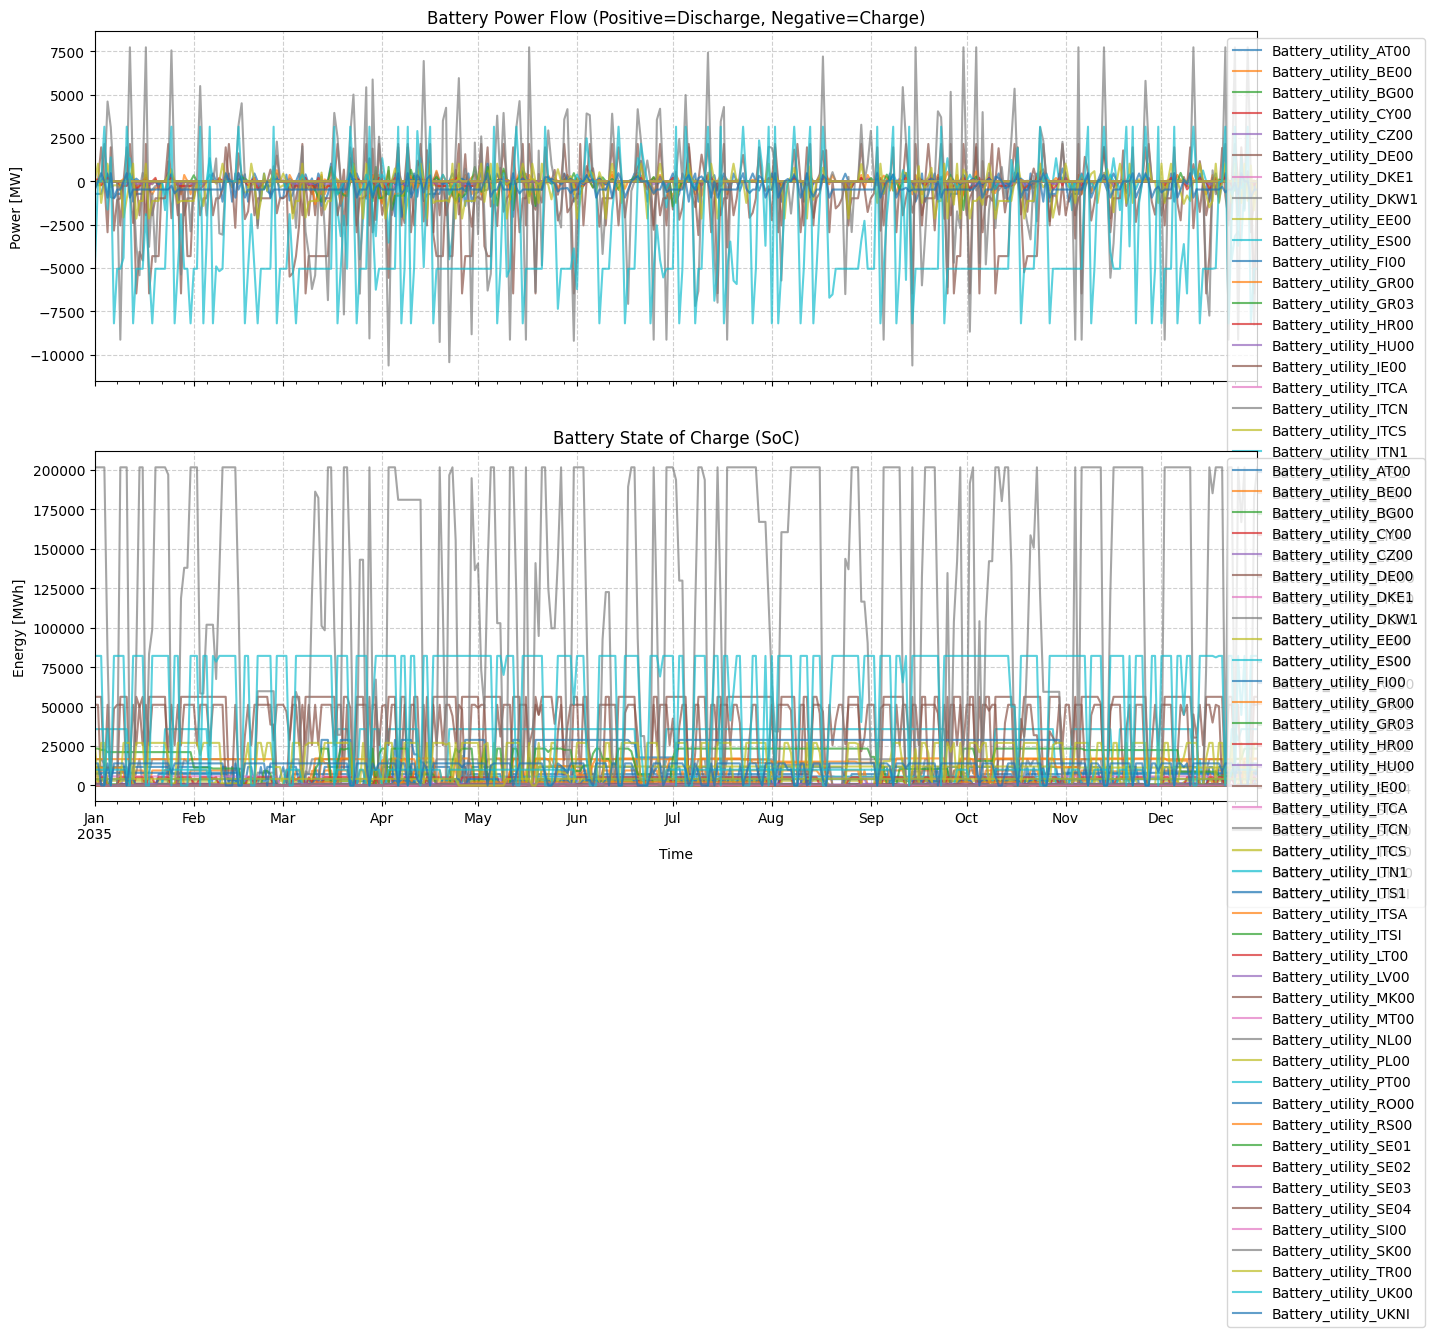

--- Battery Operational Summary ---


,Max Charging [MW],Max Discharging [MW],Max SoC [MWh],Total Throughput [GWh]
name,,,,
Battery_utility_AT00,-326.086957,276.000000,7200.000000,278.686934
Battery_utility_BE00,-749.897825,364.669025,9513.105011,1330.264583
Battery_utility_BG00,-124.074074,100.500000,2680.000000,47.599024
Battery_utility_CY00,-31.433333,15.833333,400.000000,27.217559
Battery_utility_CZ00,-467.678508,155.712300,4062.060000,365.631972
Battery_utility_DE00,-6464.916275,2152.476467,56151.560000,12076.924749
Battery_utility_DKE1,-77.825200,22.026000,587.360000,171.609492
Battery_utility_DKW1,-525.310000,489.564542,16610.610000,1283.512351
Battery_utility_EE00,-345.400000,115.000000,3000.000000,938.872874


In [54]:
import matplotlib.pyplot as plt

# 1. Identify Battery Assets
battery_units = n_26.storage_units[n_26.storage_units.carrier == 'battery'].index

if not battery_units.empty:
    # 2. Extract Power and State of Charge
    # In PyPSA storage units: positive p = discharging (supply), negative p = charging (load)
    battery_power = n_26.storage_units_t.p[battery_units]
    battery_soc = n_26.storage_units_t.state_of_charge[battery_units]

    # 3. Plotting
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

    # Plot Power Flow
    battery_power.plot(ax=ax1, alpha=0.7)
    ax1.set_title('Battery Power Flow (Positive=Discharge, Negative=Charge)')
    ax1.set_ylabel('Power [MW]')
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.legend(loc='upper right', bbox_to_anchor=(1.15, 1))

    # Plot State of Charge
    battery_soc.plot(ax=ax2, alpha=0.7)
    ax2.set_title('Battery State of Charge (SoC)')
    ax2.set_ylabel('Energy [MWh]')
    ax2.set_xlabel('Time')
    ax2.grid(True, linestyle='--', alpha=0.6)
    ax2.legend(loc='upper right', bbox_to_anchor=(1.15, 1))

    plt.tight_layout()
    plt.show()

    # 4. Summary Statistics
    summary = pd.DataFrame({
        'Max Charging [MW]': battery_power.min(),
        'Max Discharging [MW]': battery_power.max(),
        'Max SoC [MWh]': battery_soc.max(),
        'Total Throughput [GWh]': (battery_power.abs() * n_26.snapshot_weightings.iloc[0,0]).sum() / 1000
    })
    print("--- Battery Operational Summary ---")
    display(summary)
else:
    print("No battery storage units found in the network.")

In [55]:
import pandas as pd

# Identify German battery units
de_batteries = [b for b in n_26.storage_units.index if 'DE00' in b and n_26.storage_units.at[b, 'carrier'] == 'battery']

if de_batteries:
    sw = n_26.snapshot_weightings.iloc[0,0]
    # p > 0 is discharging, p < 0 is charging
    p = n_26.storage_units_t.p[de_batteries]

    discharging_mwh = p[p > 0].sum().sum() * sw
    charging_mwh = p[p < 0].sum().sum() * sw

    de_battery_sum = pd.DataFrame({
        'Metric': ['Total Discharging', 'Total Charging', 'Net Balance', 'Total Throughput'],
        'Value [GWh]': [
            discharging_mwh / 1000,
            charging_mwh / 1000,
            (discharging_mwh + charging_mwh) / 1000,
            (abs(discharging_mwh) + abs(charging_mwh)) / 1000
        ]
    })

    print("--- Annual Battery Energy Sums for Germany (DE00) ---")
    display(de_battery_sum.style.format({'Value [GWh]': '{:,.2f}'}))
else:
    print("No battery units found for Germany (DE00).")

--- Annual Battery Energy Sums for Germany (DE00) ---


,Metric,Value [GWh]
0,Total Discharging,"2,734.76"
1,Total Charging,"-9,342.16"
2,Net Balance,"-6,607.40"
3,Total Throughput,"12,076.92"


In [56]:
import pandas as pd

# 1. Identify all slack generators in the network
slack_gen_indices = n_26.generators.index[n_26.generators.index.str.contains('Slack')]

if not slack_gen_indices.empty:
    sw = n_26.snapshot_weightings.iloc[0,0]
    # Calculate total energy (MWh) for each slack generator
    slack_energy = n_26.generators_t.p[slack_gen_indices].sum() * sw

    # Combine with basic info
    slack_info = pd.DataFrame({
        'Bus': n_26.generators.loc[slack_gen_indices, 'bus'],
        'Carrier': n_26.generators.loc[slack_gen_indices, 'carrier'],
        'Total Generation [MWh]': slack_energy
    })

    # Filter for active slacks
    active_slacks = slack_info[slack_info['Total Generation [MWh]'] > 0.1]

    print(f"Total slack generators found: {len(slack_info)}")
    print(f"Number of active slacks: {len(active_slacks)}")

    if not active_slacks.empty:
        print("\n--- Active Slack Generators (Generation > 0) ---")
        display(active_slacks.sort_values(by='Total Generation [MWh]', ascending=False))
    else:
        print("\nAll slack generators have zero output (The system is balanced).")
else:
    print("No slack generators found in the network.")

Total slack generators found: 90
Number of active slacks: 25

--- Active Slack Generators (Generation > 0) ---


,Bus,Carrier,Total Generation [MWh]
name,,,
Slack_TR00,TR00_electricity_market,AC,1.967095e+07
Slack_NOS3,NOS3_electricity_market,AC,1.073082e+07
Slack_H2_SKh2E,SKh2E,H2,9.875487e+06
Slack_H2_ROh2,ROh2,H2,9.408776e+06
Slack_H2_SKh2W,SKh2W,H2,8.462864e+06
Slack_NON1,NON1_electricity_market,AC,8.118043e+06
Slack_H2_HUh2,HUh2,H2,8.002655e+06
Slack_NOM1,NOM1_electricity_market,AC,7.219333e+06
Slack_LUF1,LUF1_electricity_market,AC,6.420830e+06


In [57]:
import pandas as pd

# 1. Reuse identified slack indices from previous cell
if not slack_gen_indices.empty:
    sw = n_26.snapshot_weightings.iloc[0,0]
    # Calculate total energy in TWh (MWh / 1,000,000)
    slack_energy_twh = (n_26.generators_t.p[slack_gen_indices].sum() * sw) / 1e6

    # Combine with metadata
    slack_twh_df = pd.DataFrame({
        'Bus': n_26.generators.loc[slack_gen_indices, 'bus'],
        'Carrier': n_26.generators.loc[slack_gen_indices, 'carrier'],
        'Annual Slack Generation [TWh]': slack_energy_twh
    })

    # Filter for active slacks (> 1e-7 TWh to avoid precision noise)
    active_slacks_twh = slack_twh_df[slack_twh_df['Annual Slack Generation [TWh]'] > 1e-7]

    print(f"Summary: Found {len(active_slacks_twh)} active slack nodes.")

    # Display styled table
    display(active_slacks_twh.sort_values(by='Annual Slack Generation [TWh]', ascending=False).style.format({
        'Annual Slack Generation [TWh]': '{:,.4f}'
    }))
else:
    print("No slack generators found.")

Summary: Found 25 active slack nodes.


,Bus,Carrier,Annual Slack Generation [TWh]
name,,,
Slack_TR00,TR00_electricity_market,AC,19.6709
Slack_NOS3,NOS3_electricity_market,AC,10.7308
Slack_H2_SKh2E,SKh2E,H2,9.8755
Slack_H2_ROh2,ROh2,H2,9.4088
Slack_H2_SKh2W,SKh2W,H2,8.4629
Slack_NON1,NON1_electricity_market,AC,8.1180
Slack_H2_HUh2,HUh2,H2,8.0027
Slack_NOM1,NOM1_electricity_market,AC,7.2193
Slack_LUF1,LUF1_electricity_market,AC,6.4208


In [58]:
import pandas as pd

zone = 'AT00'
elec_bus = f'{zone}_electricity_market'
prosumer_bus = f'{zone}_prosumer_bus'

# 1. Extract standard generators (Utility PV, Nuclear, Wind, etc.)
hu_generators = n_26.generators[n_26.generators.bus == elec_bus][['carrier', 'p_nom']]

# 2. Extract Prosumer assets (specifically Rooftop PV)
if prosumer_bus in n_26.buses.index:
    hu_prosumer = n_26.generators[n_26.generators.bus == prosumer_bus][['carrier', 'p_nom']]
    # Rename prosumer solar to distinguish it
    hu_prosumer['carrier'] = hu_prosumer['carrier'].replace('solar', 'solar_rooftop')
    hu_generators = pd.concat([hu_generators, hu_prosumer])

# 3. Extract thermal plants and Interconnectors (Links where bus1 is the electricity market)
hu_links = n_26.links[n_26.links.bus1 == elec_bus][['carrier', 'p_nom']]

# Combine all assets
hu_all_assets = pd.concat([hu_generators, hu_links])

# Convert to GW
hu_all_assets['p_nom_gw'] = hu_all_assets['p_nom'] / 1000.0

print(f"--- Installed Capacities for {zone} (GW) ---")
if not hu_all_assets.empty:
    display(hu_all_assets.sort_values(by='p_nom_gw', ascending=False)[['carrier', 'p_nom_gw']])

    # Calculate specific Solar sum
    solar_total = hu_all_assets[hu_all_assets['carrier'].isin(['solar', 'solar_rooftop'])]['p_nom_gw'].sum()
    print(f"\nTotal Combined Solar (Utility + Rooftop): {solar_total:.3f} GW")
else:
    print(f"No assets found for {zone}")

--- Installed Capacities for AT00 (GW) ---


,carrier,p_nom_gw
name,,
AC_link_SRES_ATh2_el_market,AC,1000.000000
PV_AT00,solar,20.499950
Wind_Onshore_AT00,wind_onshore,10.000005
AC_link_int_DE00_AT00,cross_border,7.550000
RoR_AT00,hydro,5.414819
Gas_turbine_AT00,natural_gas,1.833790
AC_link_int_CH00_AT00,cross_border,1.200000
AC_link_int_SI00_AT00,cross_border,0.950000
AC_link_int_CZ00_AT00,cross_border,0.900000



Total Combined Solar (Utility + Rooftop): 20.500 GW


In [59]:
import pandas as pd

# Targeting Austria (AT00) as per previous context
zone = 'AT00'
elec_bus = f'{zone}_electricity_market'
prosumer_bus = f'{zone}_prosumer_bus'
sw = n_26.snapshot_weightings.iloc[0,0]

# 1. Extract Generation from Generators (RES, Nuclear, RoR)
hu_gen_indices = n_26.generators[(n_26.generators.bus == elec_bus) | (n_26.generators.bus == prosumer_bus)].index
hu_gen_data = n_26.generators.loc[hu_gen_indices, ['carrier']].copy()
hu_gen_data['generation_mwh'] = n_26.generators_t.p[hu_gen_indices].sum() * sw

# Refine Rooftop and RoR labels
mask_prosumer = n_26.generators.loc[hu_gen_indices, 'bus'] == prosumer_bus
hu_gen_data.loc[mask_prosumer & (hu_gen_data.carrier == 'solar'), 'carrier'] = 'solar_rooftop'
hu_gen_data.loc[hu_gen_data.index.str.contains('RoR'), 'carrier'] = 'hydro_RoR'

# 2. Extract Generation from Storage Units (Reservoir, Pondage, PHS)
hu_su_indices = n_26.storage_units[n_26.storage_units.bus == elec_bus].index
hu_su_data = n_26.storage_units.loc[hu_su_indices, ['carrier']].copy()
# p_dispatch represents generation (positive values)
hu_su_data['generation_mwh'] = n_26.storage_units_t.p_dispatch[hu_su_indices].sum() * sw

# Refine specific Hydro storage categories
hu_su_data.loc[hu_su_data.index.str.contains('Reservoir'), 'carrier'] = 'hydro_Reservoir'
hu_su_data.loc[hu_su_data.index.str.contains('Pondage'), 'carrier'] = 'hydro_Pondage'
hu_su_data.loc[hu_su_data.index.str.contains('PHS'), 'carrier'] = 'hydro_PS_turbine'

# 3. Extract Generation from Links (Thermal, Interconnectors)
hu_link_indices = n_26.links[n_26.links.bus1 == elec_bus].index
hu_link_gen = pd.DataFrame(index=hu_link_indices)
hu_link_gen['carrier'] = n_26.links.loc[hu_link_indices, 'carrier']
hu_link_gen['generation_mwh'] = n_26.links_t.p1[hu_link_indices].sum() * sw * -1

# 4. Combine and Aggregate
hu_energy_all = pd.concat([hu_gen_data, hu_su_data, hu_link_gen])
hu_energy_summary = hu_energy_all.groupby('carrier')['generation_mwh'].sum().reset_index()

# Convert to TWh
hu_energy_summary['Generation [TWh]'] = hu_energy_summary['generation_mwh'] / 1e6

print(f"--- Detailed Annual Generation Breakdown for {zone} (TWh) ---")
display(hu_energy_summary.sort_values(by='Generation [TWh]', ascending=False)[['carrier', 'Generation [TWh]']])

# Calculate Solar and Hydro Totals
solar_twh = hu_energy_summary[hu_energy_summary['carrier'].isin(['solar', 'solar_rooftop'])]['Generation [TWh]'].sum()
hydro_twh = hu_energy_summary[hu_energy_summary['carrier'].str.startswith('hydro')]['Generation [TWh]'].sum()

print(f"\nTotal Combined Solar: {solar_twh:.3f} TWh")
print(f"Total Combined Hydro: {hydro_twh:.3f} TWh")

--- Detailed Annual Generation Breakdown for AT00 (TWh) ---


,carrier,Generation [TWh]
3,cross_border,38.219772
11,solar,25.135846
7,hydro_RoR,25.106992
12,wind_onshore,23.970998
6,hydro_Reservoir,5.570841
1,RES,4.461112
4,hydro_PS_turbine,3.315538
8,natural_gas,1.729124
10,other_non_res,0.562821
5,hydro_Pondage,0.208399



Total Combined Solar: 25.136 TWh
Total Combined Hydro: 34.202 TWh


In [60]:
ror_profile_raw = pd.Series(model_data['Zonal']['AT00'].get('hydro', {}).get('profiles', {}).get('RoR_MW', []))

if not ror_profile_raw.empty:
    print(f"--- Run-of-River Profile Analysis (AT00) ---")
    print(f"Max Value: {ror_profile_raw.max():.2f}")
    print(f"Min Value: {ror_profile_raw.min():.2f}")
    print(f"Mean Value: {ror_profile_raw.mean():.2f}")
    print("\nPreview (First 5 values):")
    print(ror_profile_raw.head())

    if ror_profile_raw.max() > 1.1:
        print("\nConclusion: The profile appears to be in ABSOLUTE MW.")
    else:
        print("\nConclusion: The profile appears to be NORMALIZED (Capacity Factor).")
else:
    print("No RoR_MW profile found for AT00.")

--- Run-of-River Profile Analysis (AT00) ---
Max Value: 4043.83
Min Value: 1875.79
Mean Value: 2866.09

Preview (First 5 values):
2035-01-01 00:00:00    1950.291667
2035-01-01 01:00:00    1950.291667
2035-01-01 02:00:00    1950.291667
2035-01-01 03:00:00    1950.291667
2035-01-01 04:00:00    1950.291667
dtype: float64

Conclusion: The profile appears to be in ABSOLUTE MW.


In [61]:
import pandas as pd

# Identify pondage assets in AT00
pondage_assets = n_26.storage_units[n_26.storage_units.index.str.contains('Pondage_AT00')]

if not pondage_assets.empty:
    capacity_mw = pondage_assets['p_nom'].sum()
    print(f"Total Pondage Hydro Capacity in AT00: {capacity_mw:.2f} MW ({capacity_mw/1000:.2f} GW)")
    display(pondage_assets[['p_nom', 'carrier', 'max_hours']])
else:
    print("No pondage hydro assets found for AT00 in the network storage units.")

Total Pondage Hydro Capacity in AT00: 1150.01 MW (1.15 GW)


,p_nom,carrier,max_hours
name,,,
HPP_Pondage_AT00,1150.007,hydro,4.621674
